# Model Comparison — Focal Mask U-Net (All Features vs. Selected 32 vs. Original 10)

This notebook trains two segmentation models on Myanmar PRIOGRID cells:
1. **all_features (93ch)** — U-Net trained on all 93 features from the feature store.
2. **important ≥1% (32ch)** — U-Net retrained using only the 32 features whose
   permutation importance exceeded 1% of baseline macro-F1 (pre-computed and saved to
   `data/processed/selected_features_32.csv`).
3. **original 10ch** — Earlier baseline trained on the original hand-crafted 10 features.
4. **random baseline** — Proportional random draw from the training class distribution.

All models use the same U-Net backbone (ResNet-34 encoder, ImageNet weights),
focal mask loss, and temporal train/val split (train ≤ 2025-01, val > 2025-01).

**How predictions are generated**: for each validation month the full raster
(H × W spatial grid) is passed through the model in one forward pass. The argmax
over the 3-class softmax output gives the predicted control label for each cell.
Probability scores (gov / opo / uncertain) come from the softmax probabilities
at each pixel position.

In [79]:
import copy
import os
import random
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import torch.optim as optim
import segmentation_models_pytorch as smp
from pathlib import Path
from scipy.ndimage import binary_dilation
from sklearn.metrics import f1_score
from torch.utils.data import Dataset, DataLoader

In [80]:
# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 20269999
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
if hasattr(torch.backends, 'mps'):
    torch.mps.manual_seed(SEED) if hasattr(torch.mps, 'manual_seed') else None
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False
os.environ['PYTHONHASHSEED'] = str(SEED)
print(f'Global seed fixed: {SEED}')

Global seed fixed: 20269999


In [81]:
# ── Config ────────────────────────────────────────────────────────────────────
TRAIN_CUTOFF     = '2025-01'
NEIGHBOR_RADIUS  = 1
FOCAL_OUT_WEIGHT = 0.0
NUM_EPOCHS       = 200
BATCH_SIZE       = 8
LEARNING_RATE    = 1e-4
FREEZE_EPOCHS    = 30
UNFREEZE_LR      = 1e-5

In [82]:
# ── Paths ─────────────────────────────────────────────────────────────────────
PROJECT_ROOT = Path().resolve().parents[1]  # notebook lives in notebooks/modeling_pipeline/
DATA_PROC    = PROJECT_ROOT / 'data' / 'processed'
MODELS_DIR   = PROJECT_ROOT / 'models'
OUT_DIR      = MODELS_DIR / 'focal_mask_all_features'
OUT_DIR.mkdir(parents=True, exist_ok=True)

WEIGHTS_PATH     = OUT_DIR / 'weights.pt'
PREDICTIONS_PATH = OUT_DIR / 'predictions.csv'
FOCAL_MASK_PATH  = MODELS_DIR / f'focal_mask_r{NEIGHBOR_RADIUS}.npy'
IMPORTANCE_PATH  = OUT_DIR / 'feature_importance.csv'
print(f'OUT_DIR: {OUT_DIR}')

OUT_DIR: /Users/felipe/Documents/BSE/Thesis/territorial_control_dsdm_master_project/models/focal_mask_all_features


In [83]:
# ── Load data ─────────────────────────────────────────────────────────────────
target = pd.read_parquet(DATA_PROC / '10_target_variable.parquet')
target['year_month'] = target['year_month'].astype(str)
print(f'Target rows: {len(target):,}  |  months: {target["year_month"].nunique()}'
      f'  |  cells: {target["priogrid_gid"].nunique()}')
print('\nClass distribution:')
print(target['target'].value_counts())

features = pd.read_csv(DATA_PROC / 'myanmar_feature_store.csv')
features['year_month'] = features['year_month'].astype(str)

Target rows: 5,238  |  months: 29  |  cells: 185

Class distribution:
target
gov          3303
opo          1110
uncertain     825
Name: count, dtype: int64


In [84]:
# ── Dynamic feature selection ─────────────────────────────────────────────────
# Exclude identifiers, datetime strings, and categorical columns
EXCLUDE_COLS   = {'priogrid_gid', 'year_month', 'year_month_dt', 'adm_1'}
INPUT_FEATURES = [c for c in features.columns if c not in EXCLUDE_COLS]
NUM_CHANNELS   = len(INPUT_FEATURES)
print(f'Input features ({NUM_CHANNELS}):')
for i, f in enumerate(INPUT_FEATURES):
    print(f'  [{i:2d}] {f}')

Input features (93):
  [ 0] total_events
  [ 1] is_statebased
  [ 2] is_onesided
  [ 3] gov_vs_civilians
  [ 4] total_fatalities
  [ 5] deaths_a
  [ 6] deaths_b
  [ 7] deaths_civilians
  [ 8] events_gov
  [ 9] events_nug
  [10] events_kio
  [11] events_ula
  [12] events_knu
  [13] events_mndaa
  [14] events_pslf
  [15] events_cnf
  [16] events_rcss
  [17] events_uwsa
  [18] n_unique_dyads
  [19] total_events_lag1
  [20] total_fatalities_lag1
  [21] events_gov_lag1
  [22] events_nug_lag1
  [23] gov_vs_civilians_lag1
  [24] is_onesided_lag1
  [25] total_events_lag3
  [26] total_fatalities_lag3
  [27] events_gov_lag3
  [28] events_nug_lag3
  [29] gov_vs_civilians_lag3
  [30] is_onesided_lag3
  [31] total_events_lag6
  [32] total_fatalities_lag6
  [33] events_gov_lag6
  [34] events_nug_lag6
  [35] gov_vs_civilians_lag6
  [36] is_onesided_lag6
  [37] total_events_roll3m
  [38] total_fatalities_roll3m
  [39] total_events_roll6m
  [40] total_fatalities_roll6m
  [41] gov_event_share
  [42] nug

In [85]:
# ── Raster construction ───────────────────────────────────────────────────────
LABEL_MAP   = {'gov': 0, 'opo': 1, 'uncertain': 2}
INV_LABEL   = {v: k for k, v in LABEL_MAP.items()}
CLASS_NAMES = ['gov', 'opo', 'uncertain']


def gid_to_rowcol(gid):
    return (gid - 1) // 720, (gid - 1) % 720


all_gids   = features['priogrid_gid'].unique()
gid_coords = {}
for gid in all_gids:
    r, c = gid_to_rowcol(gid)
    gid_coords[gid] = {'global_row': r, 'global_col': c}
coords_df = pd.DataFrame.from_dict(gid_coords, orient='index')
coords_df.index.name = 'priogrid_gid'

min_global_row = coords_df['global_row'].min()
min_global_col = coords_df['global_col'].min()
coords_df['local_row'] = coords_df['global_row'] - min_global_row
coords_df['local_col'] = coords_df['global_col'] - min_global_col

RASTER_H = coords_df['local_row'].max() + 1
RASTER_W = coords_df['local_col'].max() + 1
PAD_H    = int(np.ceil(RASTER_H / 8) * 8)
PAD_W    = int(np.ceil(RASTER_W / 8) * 8)

gid_to_local = coords_df[['local_row', 'local_col']].to_dict('index')

# Left join: recovers zero-event cells with Wikipedia annotations
labelled = target[['priogrid_gid', 'year_month', 'target']].merge(
    features, on=['priogrid_gid', 'year_month'], how='left'
)
labelled[INPUT_FEATURES] = labelled[INPUT_FEATURES].fillna(0.0)
labelled['label_int'] = labelled['target'].map(LABEL_MAP)

for gid in labelled['priogrid_gid'].unique():
    if gid in gid_to_local:
        continue
    r0, c0 = gid_to_rowcol(gid)
    lr = r0 - min_global_row
    lc = c0 - min_global_col
    if 0 <= lr < PAD_H and 0 <= lc < PAD_W:
        gid_to_local[gid] = {'local_row': lr, 'local_col': lc}

n_recovered = len(labelled['priogrid_gid'].unique()) - len(all_gids)
print(f'Left join: {labelled["priogrid_gid"].nunique()} unique cells'
      f'  ({n_recovered:+d} vs inner-join baseline)')

Left join: 185 unique cells  (-14 vs inner-join baseline)


In [86]:
# ── Normalisation ─────────────────────────────────────────────────────────────
train_mask_rows   = labelled['year_month'] <= TRAIN_CUTOFF
train_months_used = sorted(labelled.loc[train_mask_rows, 'year_month'].unique())
feat_means = labelled.loc[train_mask_rows, INPUT_FEATURES].mean()
feat_stds  = labelled.loc[train_mask_rows, INPUT_FEATURES].std().replace(0, 1)
print(f'Normalisation fit on {len(train_months_used)} training months: '
      f'{train_months_used[0]} → {train_months_used[-1]}')
labelled[INPUT_FEATURES] = (labelled[INPUT_FEATURES] - feat_means) / feat_stds

Normalisation fit on 15 training months: 2023-11 → 2025-01


In [87]:
# ── Build raster arrays ───────────────────────────────────────────────────────
months_with_labels = sorted(labelled['year_month'].unique())
X_rasters, y_rasters, masks_r, month_keys = [], [], [], []

for month in months_with_labels:
    md_ = labelled[labelled['year_month'] == month]
    X_r = np.zeros((PAD_H, PAD_W, NUM_CHANNELS), dtype=np.float32)
    y_r = np.full((PAD_H, PAD_W), fill_value=-1, dtype=np.int64)
    msk = np.zeros((PAD_H, PAD_W), dtype=np.uint8)
    for _, row in md_.iterrows():
        gid = row['priogrid_gid']
        if gid not in gid_to_local:
            continue
        lr, lc         = gid_to_local[gid]['local_row'], gid_to_local[gid]['local_col']
        X_r[lr, lc, :] = row[INPUT_FEATURES].values
        y_r[lr, lc]    = row['label_int']
        msk[lr, lc]    = 1
    X_rasters.append(np.transpose(X_r, (2, 0, 1)))
    y_rasters.append(y_r)
    masks_r.append(msk)
    month_keys.append(month)

X_array = np.stack(X_rasters)
y_array = np.stack(y_rasters)
m_array = np.stack(masks_r)

train_idx = [i for i, m in enumerate(month_keys) if m <= TRAIN_CUTOFF]
val_idx   = [i for i, m in enumerate(month_keys) if m >  TRAIN_CUTOFF]
X_train, y_train, m_train = X_array[train_idx], y_array[train_idx], m_array[train_idx]
X_val,   y_val,   m_val   = X_array[val_idx],   y_array[val_idx],   m_array[val_idx]

print(f'Raster shape: {X_array.shape}  (months x channels x H x W)')
print(f'Train months: {len(train_idx)}  ({month_keys[train_idx[0]]} → {month_keys[train_idx[-1]]})')
print(f'Val   months: {len(val_idx)}   ({month_keys[val_idx[0]]} → {month_keys[val_idx[-1]]})')

Raster shape: (29, 93, 40, 16)  (months x channels x H x W)
Train months: 15  (2023-11 → 2025-01)
Val   months: 14   (2025-02 → 2026-03)


In [88]:
# ── Focal mask ────────────────────────────────────────────────────────────────
label_by_gid  = labelled.groupby('priogrid_gid')['label_int'].nunique()
changing_gids = set(label_by_gid[label_by_gid > 1].index)

changing_raster = np.zeros((PAD_H, PAD_W), dtype=bool)
for gid in changing_gids:
    if gid in gid_to_local:
        lr, lc = gid_to_local[gid]['local_row'], gid_to_local[gid]['local_col']
        changing_raster[lr, lc] = True

struct        = np.ones((2 * NEIGHBOR_RADIUS + 1, 2 * NEIGHBOR_RADIUS + 1), dtype=bool)
focal_mask_np = binary_dilation(changing_raster, structure=struct)

np.save(FOCAL_MASK_PATH, focal_mask_np)
print(f'Focal mask saved: {FOCAL_MASK_PATH}'
      f'  ({focal_mask_np.sum()} focal pixels, {len(changing_gids)} changing cells)')

Focal mask saved: /Users/felipe/Documents/BSE/Thesis/territorial_control_dsdm_master_project/models/focal_mask_r1.npy  (285 focal pixels, 94 changing cells)


In [89]:
# ── Device ────────────────────────────────────────────────────────────────────
if torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
elif torch.cuda.is_available():
    DEVICE = torch.device('cuda')
else:
    DEVICE = torch.device('cpu')
print(f'Device: {DEVICE}')

Device: mps


In [90]:
# ── Model and loss ────────────────────────────────────────────────────────────
NUM_CLASSES     = 3
ENCODER_NAME    = 'resnet34'
ENCODER_WEIGHTS = 'imagenet'

label_counts         = np.array([
    (labelled['label_int'] == 0).sum(),
    (labelled['label_int'] == 1).sum(),
    (labelled['label_int'] == 2).sum(),
])
class_weights_np     = len(labelled) / (NUM_CLASSES * label_counts)
class_weights_tensor = torch.tensor(class_weights_np, dtype=torch.float32).to(DEVICE)

dice_loss_fn      = smp.losses.DiceLoss(mode='multiclass', from_logits=True, smooth=1.0)
focal_mask_tensor = torch.from_numpy(focal_mask_np).bool().to(DEVICE)


def combined_loss(predictions, targets, mask):
    safe_targets = targets.clone()
    safe_targets[mask == 0] = 0
    preds_hwc   = predictions.permute(0, 2, 3, 1)
    valid_preds = preds_hwc[mask == 1]
    valid_tgts  = targets[mask == 1]
    if valid_preds.shape[0] == 0:
        return torch.tensor(0.0, requires_grad=True, device=predictions.device)
    ce = F.cross_entropy(valid_preds, valid_tgts, weight=class_weights_tensor)
    dc = dice_loss_fn(predictions, safe_targets)
    return 0.5 * ce + 0.5 * dc


def focal_combined_loss(predictions, targets, label_mask):
    B           = predictions.shape[0]
    focal_broad = focal_mask_tensor.unsqueeze(0).expand(B, -1, -1)
    pixel_w     = torch.where(
        focal_broad,
        label_mask.float(),
        label_mask.float() * FOCAL_OUT_WEIGHT,
    )
    safe_targets = targets.clone()
    safe_targets[label_mask == 0] = 0
    ce_per_pixel = F.cross_entropy(
        predictions, safe_targets,
        weight=class_weights_tensor,
        reduction='none',
    )
    n_effective = pixel_w.sum() + 1e-8
    ce = (ce_per_pixel * pixel_w).sum() / n_effective
    dc = dice_loss_fn(predictions, safe_targets)
    return 0.5 * ce + 0.5 * dc


def build_model():
    random.seed(SEED); np.random.seed(SEED)
    torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
    return smp.Unet(
        encoder_name=ENCODER_NAME, encoder_weights=ENCODER_WEIGHTS,
        in_channels=NUM_CHANNELS,  classes=NUM_CLASSES,
        activation=None, decoder_channels=(128, 64, 32, 16), encoder_depth=4,
    ).to(DEVICE)


def build_optimizer(model):
    params = list(model.decoder.parameters()) + list(model.segmentation_head.parameters())
    opt    = optim.Adam(params, lr=LEARNING_RATE, weight_decay=1e-5)
    sch    = optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', patience=10, factor=0.5)
    return opt, sch

In [91]:
# ── Dataset ───────────────────────────────────────────────────────────────────
class MyanmarRasterDataset(Dataset):
    def __init__(self, X, y, mask, augment=False):
        self.X       = X.astype(np.float32)
        self.y       = y.astype(np.int64)
        self.mask    = mask.astype(np.uint8)
        self.augment = augment
        self.T       = len(X)

    def __len__(self): return self.T

    def __getitem__(self, idx):
        X, y, mask = (torch.from_numpy(self.X[idx]),
                      torch.from_numpy(self.y[idx]),
                      torch.from_numpy(self.mask[idx]))
        if self.augment:
            if torch.rand(1).item() > 0.5:
                X, y, mask = torch.flip(X, [2]), torch.flip(y, [1]), torch.flip(mask, [1])
            if torch.rand(1).item() > 0.7:
                X, y, mask = torch.flip(X, [1]), torch.flip(y, [0]), torch.flip(mask, [0])
            X = X + torch.randn_like(X) * 0.05
        return X, y, mask


def seed_worker(worker_id):
    np.random.seed(SEED + worker_id)
    random.seed(SEED + worker_id)


def make_loaders():
    g        = torch.Generator(); g.manual_seed(SEED)
    train_ds = MyanmarRasterDataset(X_train, y_train, m_train, augment=True)
    val_ds   = MyanmarRasterDataset(X_val,   y_val,   m_val,   augment=False)
    tr_ld = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                       num_workers=0, drop_last=False,
                       generator=g, worker_init_fn=seed_worker)
    va_ld = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    return tr_ld, va_ld


def compute_metrics(logits, targets, mask):
    preds   = torch.argmax(logits, dim=1)
    vp, vt  = preds[mask == 1], targets[mask == 1]
    if len(vt) == 0:
        return {'overall_acc': 0.0}
    acc     = (vp == vt).float().mean().item()
    cls_acc = {}
    for c, name in enumerate(CLASS_NAMES):
        cm = vt == c
        cls_acc[name] = (vp[cm] == c).float().mean().item() if cm.sum() > 0 else float('nan')
    return {'overall_acc': acc, **cls_acc}


def freeze_encoder(model):
    for p in model.encoder.parameters():
        p.requires_grad = False


def unfreeze_encoder(model, optimizer, new_lr):
    for p in model.encoder.parameters():
        p.requires_grad = True
    optimizer.add_param_group({'params': list(model.encoder.parameters()), 'lr': new_lr})

In [92]:
# ── Training loop ─────────────────────────────────────────────────────────────
model        = build_model()
opt, sched   = build_optimizer(model)
tr_ld, va_ld = make_loaders()

history = {k: [] for k in ['train_loss', 'val_loss', 'train_acc', 'val_acc',
                            'val_acc_gov', 'val_acc_opo', 'val_acc_uncertain', 'lr']}
best_val_loss, best_wts = float('inf'), None
freeze_encoder(model)

print(f'\nTraining: {NUM_EPOCHS} epochs, TRAIN_CUTOFF={TRAIN_CUTOFF}')
for epoch in range(1, NUM_EPOCHS + 1):
    if epoch == FREEZE_EPOCHS + 1:
        print(f'  ── Phase 2: unfreezing encoder (epoch {epoch})')
        unfreeze_encoder(model, opt, UNFREEZE_LR)

    model.train()
    e_loss, e_acc, nb = 0.0, 0.0, 0
    for Xb, yb, mb in tr_ld:
        Xb, yb, mb = Xb.to(DEVICE), yb.to(DEVICE), mb.to(DEVICE)
        opt.zero_grad()
        preds = model(Xb)
        loss  = focal_combined_loss(preds, yb, mb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        opt.step()
        with torch.no_grad():
            m_ = compute_metrics(preds, yb, mb)
        e_loss += loss.item(); e_acc += m_['overall_acc']; nb += 1
    avg_tl, avg_ta = e_loss / nb, e_acc / nb

    model.eval()
    e_loss, e_acc, nb = 0.0, 0.0, 0
    cls_ = {'gov': [], 'opo': [], 'uncertain': []}
    with torch.no_grad():
        for Xb, yb, mb in va_ld:
            Xb, yb, mb = Xb.to(DEVICE), yb.to(DEVICE), mb.to(DEVICE)
            preds = model(Xb)
            loss  = combined_loss(preds, yb, mb)
            m_    = compute_metrics(preds, yb, mb)
            e_loss += loss.item(); e_acc += m_['overall_acc']; nb += 1
            for c in CLASS_NAMES:
                if not np.isnan(m_.get(c, float('nan'))):
                    cls_[c].append(m_[c])
    avg_vl, avg_va = e_loss / nb, e_acc / nb
    avg_cls = {c: np.mean(v) if v else float('nan') for c, v in cls_.items()}

    sched.step(avg_vl)
    history['train_loss'].append(avg_tl); history['val_loss'].append(avg_vl)
    history['train_acc'].append(avg_ta);  history['val_acc'].append(avg_va)
    history['val_acc_gov'].append(avg_cls['gov'])
    history['val_acc_opo'].append(avg_cls['opo'])
    history['val_acc_uncertain'].append(avg_cls['uncertain'])
    history['lr'].append(opt.param_groups[0]['lr'])

    if avg_vl < best_val_loss:
        best_val_loss = avg_vl
        best_wts      = copy.deepcopy(model.state_dict())
        torch.save(best_wts, WEIGHTS_PATH)
        ck = ' <- best'
    else:
        ck = ''

    if epoch % 10 == 0 or epoch == 1:
        ph = 'P1' if epoch <= FREEZE_EPOCHS else 'P2'
        print(f'  Ep {epoch:>3}/{NUM_EPOCHS} [{ph}]  '
              f'tr {avg_tl:.3f}/{avg_ta:.3f}  val {avg_vl:.3f}/{avg_va:.3f}  '
              f'[g:{avg_cls["gov"]:.2f} o:{avg_cls["opo"]:.2f} u:{avg_cls["uncertain"]:.2f}]'
              f'{ck}')

model.load_state_dict(torch.load(WEIGHTS_PATH, map_location=DEVICE))
model.eval()
print(f'\nBest val loss: {best_val_loss:.4f}  |  weights: {WEIGHTS_PATH}')


Training: 200 epochs, TRAIN_CUTOFF=2025-01
  Ep   1/200 [P1]  tr 1.114/0.246  val 0.967/0.195  [g:0.02 o:0.36 u:0.89] <- best
  Ep  10/200 [P1]  tr 0.924/0.354  val 0.963/0.329  [g:0.27 o:0.28 u:0.81]
  Ep  20/200 [P1]  tr 0.856/0.468  val 0.930/0.425  [g:0.35 o:0.43 u:0.84] <- best
  Ep  30/200 [P1]  tr 0.800/0.498  val 0.857/0.494  [g:0.42 o:0.54 u:0.86] <- best
  ── Phase 2: unfreezing encoder (epoch 31)
  Ep  40/200 [P2]  tr 0.746/0.578  val 0.824/0.541  [g:0.48 o:0.57 u:0.85]
  Ep  50/200 [P2]  tr 0.743/0.582  val 0.807/0.558  [g:0.48 o:0.63 u:0.87] <- best
  Ep  60/200 [P2]  tr 0.740/0.595  val 0.808/0.569  [g:0.51 o:0.61 u:0.84]
  Ep  70/200 [P2]  tr 0.731/0.580  val 0.797/0.582  [g:0.53 o:0.61 u:0.82] <- best
  Ep  80/200 [P2]  tr 0.711/0.623  val 0.789/0.596  [g:0.55 o:0.61 u:0.84] <- best
  Ep  90/200 [P2]  tr 0.692/0.615  val 0.785/0.585  [g:0.52 o:0.64 u:0.84]
  Ep 100/200 [P2]  tr 0.694/0.657  val 0.776/0.623  [g:0.57 o:0.65 u:0.86]
  Ep 110/200 [P2]  tr 0.678/0.663  val 

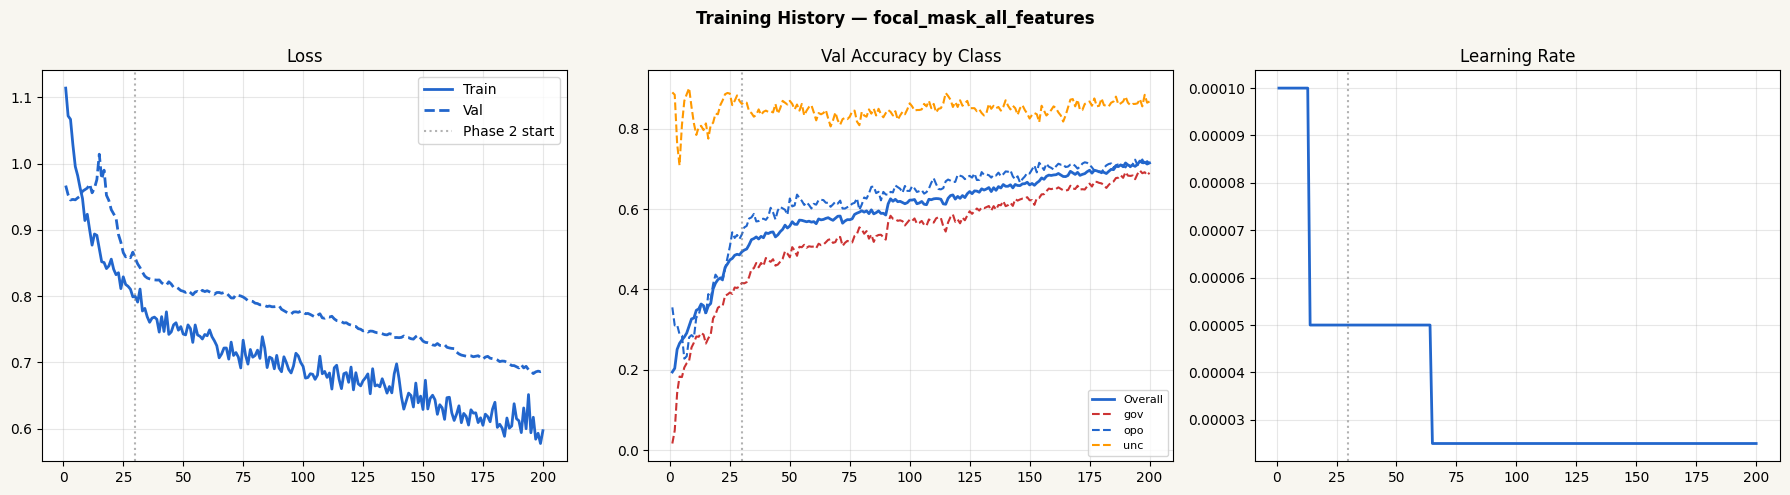

Training curves saved: /Users/felipe/Documents/BSE/Thesis/territorial_control_dsdm_master_project/models/focal_mask_all_features/training_curves.png


In [93]:
# ── Training curves ───────────────────────────────────────────────────────────
epochs_range = range(1, len(history['train_loss']) + 1)
col = '#2266CC'

fig, axes = plt.subplots(1, 3, figsize=(18, 5), facecolor='#F8F6F0')
fig.suptitle('Training History — focal_mask_all_features', fontsize=12, fontweight='bold')

ax = axes[0]
ax.plot(epochs_range, history['train_loss'], color=col, lw=2, label='Train')
ax.plot(epochs_range, history['val_loss'],   color=col, lw=2, ls='--', label='Val')
ax.axvline(FREEZE_EPOCHS, color='grey', ls=':', alpha=0.6, label='Phase 2 start')
ax.set_title('Loss'); ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(epochs_range, history['val_acc'],          color=col,       lw=2,   label='Overall')
ax.plot(epochs_range, history['val_acc_gov'],       color='#CC3333', lw=1.5, ls='--', label='gov')
ax.plot(epochs_range, history['val_acc_opo'],       color='#2266CC', lw=1.5, ls='--', label='opo')
ax.plot(epochs_range, history['val_acc_uncertain'], color='#FF9900', lw=1.5, ls='--', label='unc')
ax.axvline(FREEZE_EPOCHS, color='grey', ls=':', alpha=0.6)
ax.set_title('Val Accuracy by Class'); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

ax = axes[2]
ax.plot(epochs_range, history['lr'], color=col, lw=2)
ax.axvline(FREEZE_EPOCHS, color='grey', ls=':', alpha=0.6)
ax.set_title('Learning Rate'); ax.grid(True, alpha=0.3)

plt.tight_layout()
curves_path = OUT_DIR / 'training_curves.png'
fig.savefig(curves_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Training curves saved: {curves_path}')

In [94]:
# ── Export predictions ────────────────────────────────────────────────────────
all_pred_rows = []
with torch.no_grad():
    for i_m, month in enumerate(month_keys):
        X_t    = torch.from_numpy(X_array[i_m]).unsqueeze(0).to(DEVICE)
        logits = model(X_t)
        probs  = F.softmax(logits, dim=1)[0].cpu().numpy()
        preds  = logits.argmax(dim=1)[0].cpu().numpy()

        month_rows = labelled[labelled['year_month'] == month]
        for _, row in month_rows.iterrows():
            gid = row['priogrid_gid']
            if gid not in gid_to_local:
                continue
            lr, lc   = gid_to_local[gid]['local_row'], gid_to_local[gid]['local_col']
            pred_int = int(preds[lr, lc])
            all_pred_rows.append({
                'priogrid_gid'   : int(gid),
                'year_month'     : month,
                'pred_class'     : INV_LABEL[pred_int],
                'pred_class_int' : pred_int,
                'prob_gov'       : float(probs[0, lr, lc]),
                'prob_opo'       : float(probs[1, lr, lc]),
                'prob_uncertain' : float(probs[2, lr, lc]),
                'confidence'     : float(probs[:, lr, lc].max()),
                'true_class'     : row['target'],
                'has_label'      : True,
                'is_train_month' : month <= TRAIN_CUTOFF,
            })

pred_df = pd.DataFrame(all_pred_rows)
pred_df.to_csv(PREDICTIONS_PATH, index=False)
print(f'Predictions saved: {PREDICTIONS_PATH}  ({len(pred_df):,} rows)')
print(f'Val rows: {(pred_df["is_train_month"] == False).sum():,}')

Predictions saved: /Users/felipe/Documents/BSE/Thesis/territorial_control_dsdm_master_project/models/focal_mask_all_features/predictions.csv  (5,180 rows)
Val rows: 2,562


## Load pre-computed feature selection

Feature importance was computed via channel ablation (zeroing each input channel
in the trained all_features model and measuring the macro-F1 drop).
Features with ≥1% relative importance were retained; the full table is saved at
`models/focal_mask_all_features/feature_importance.csv`.
The 32 selected feature names are loaded here to retrain a compact model.

In [95]:
# ── Load selected features from pre-computed importance table ────────────────
imp_df       = pd.read_csv(IMPORTANCE_PATH)
IMP_FEATURES = imp_df[imp_df['relative_importance_%'] >= 1.0]['feature'].tolist()
N_IMP        = len(IMP_FEATURES)
print(f'Selected features ({N_IMP}): {IMP_FEATURES}')
print(f'\nTop-10 by relative importance:')
print(imp_df[imp_df['relative_importance_%'] >= 1.0]
      [['feature','relative_importance_%']].head(10).to_string(index=False))


Selected features (32): ['total_events_lag9', 'events_pslf_roll12m', 'total_events_lag12', 'events_gov_std3m', 'total_events_roll3m', 'total_events_roll12m', 'events_pslf_roll3m', 'events_nug_lag1', 'total_events_lag1', 'total_events_std6m', 'is_statebased', 'events_ula_roll3m', 'is_onesided_lag1', 'events_gov_roll6m', 'events_nug_roll6m', 'total_fatalities_lag6', 'total_fatalities_roll3m', 'events_nug_lag9', 'total_events_std3m', 'total_events_lag3', 'total_fatalities_lag3', 'total_events_lag6', 'events_nug_trend', 'events_nug_roll12m', 'total_fatalities_lag12', 'events_nug_lag12', 'events_cnf', 'knu_event_share', 'events_nug_std6m', 'events_mndaa_roll12m', 'events_pslf', 'events_kio_roll6m']

Top-10 by relative importance:
             feature  relative_importance_%
   total_events_lag9                   2.07
 events_pslf_roll12m                   1.89
  total_events_lag12                   1.87
    events_gov_std3m                   1.82
 total_events_roll3m                   1.80
t

## Evaluation helper

The `run_eval` function computes per-class metrics, confusion matrix, and
transition hit-rates from any prediction DataFrame that shares the same
schema (priogrid_gid, year_month, true_class, pred_class, is_train_month).
All variants are evaluated identically so results are directly comparable.

In [96]:

# ── Eval helper (mirrors focal_mask_eval.py) ──────────────────────────────────
import matplotlib.patches as mpatches
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

LABEL_MAP_R = {'gov': 0, 'opo': 1, 'uncertain': 2}


def run_eval(pred_df):
    val_df = pred_df[pred_df['is_train_month'] == False].copy()
    val_df['true_int'] = val_df['true_class'].map(LABEL_MAP_R)
    val_df['pred_int'] = val_df['pred_class'].map(LABEL_MAP_R)
    y_true = val_df['true_int'].values
    y_pred = val_df['pred_int'].values
    n_val  = len(val_df)

    report      = classification_report(y_true, y_pred, target_names=CLASS_NAMES,
                                        output_dict=True, zero_division=0)
    overall_acc = (y_true == y_pred).mean()
    cm          = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])
    cm_norm     = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-8)

    val_sorted               = val_df.sort_values(['priogrid_gid', 'year_month']).copy()
    val_sorted['prev_true']  = val_sorted.groupby('priogrid_gid')['true_int'].shift(1)
    transitions              = val_sorted.dropna(subset=['prev_true']).copy()
    transitions['prev_true'] = transitions['prev_true'].astype(int)
    transitions['is_trans']  = transitions['true_int'] != transitions['prev_true']
    trans_only = transitions[transitions['is_trans']].copy()
    stable     = transitions[~transitions['is_trans']].copy()

    trans_correct  = (trans_only['true_int'] == trans_only['pred_int']).sum()
    stable_correct = (stable['true_int']     == stable['pred_int']).sum()

    trans_only['from_cls'] = trans_only['prev_true'].map(INV_LABEL)
    trans_only['to_cls']   = trans_only['true_int'].map(INV_LABEL)
    trans_only['hit']      = trans_only['true_int'] == trans_only['pred_int']

    return {
        'report'        : report,
        'cm'            : cm,
        'cm_norm'       : cm_norm,
        'acc'           : overall_acc,
        'n_val'         : n_val,
        'trans_acc'     : trans_correct / max(len(trans_only), 1),
        'stable_acc'    : stable_correct / max(len(stable), 1),
        'n_trans'       : len(trans_only),
        'n_stable'      : len(stable),
        'trans_only_df' : trans_only,
    }


## Train compact model (32 selected features)

We retrain the same U-Net architecture from scratch using only the 32
selected channels. This tests whether the feature-selection step yields
a model that is smaller but equally or more accurate — particularly on
transition cells, which are the hardest and most policy-relevant cases.

In [97]:

# ── Train model with only ≥1% importance features ────────────────────────────
IMP_FEATURES = imp_df[imp_df['relative_importance_%'] >= 1.0]['feature'].tolist()
N_IMP        = len(IMP_FEATURES)
IMP_OUT_DIR  = MODELS_DIR / 'focal_mask_important_features'
IMP_OUT_DIR.mkdir(parents=True, exist_ok=True)
IMP_WEIGHTS_PATH     = IMP_OUT_DIR / 'weights.pt'
IMP_PREDICTIONS_PATH = IMP_OUT_DIR / 'predictions.csv'
print(f'Important features ({N_IMP}): {IMP_FEATURES}')

imp_X_rasters = []
for month in months_with_labels:
    md_ = labelled[labelled['year_month'] == month]
    X_r = np.zeros((PAD_H, PAD_W, N_IMP), dtype=np.float32)
    for _, row in md_.iterrows():
        gid = row['priogrid_gid']
        if gid not in gid_to_local:
            continue
        lr, lc         = gid_to_local[gid]['local_row'], gid_to_local[gid]['local_col']
        X_r[lr, lc, :] = row[IMP_FEATURES].values
    imp_X_rasters.append(np.transpose(X_r, (2, 0, 1)))

imp_X_array = np.stack(imp_X_rasters)
imp_X_train = imp_X_array[train_idx]
imp_X_val   = imp_X_array[val_idx]
print(f'Raster shape: {imp_X_array.shape}')

random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
imp_model = smp.Unet(
    encoder_name=ENCODER_NAME, encoder_weights=ENCODER_WEIGHTS,
    in_channels=N_IMP, classes=NUM_CLASSES,
    activation=None, decoder_channels=(128, 64, 32, 16), encoder_depth=4,
).to(DEVICE)

imp_opt, imp_sched = build_optimizer(imp_model)

g = torch.Generator(); g.manual_seed(SEED)
imp_tr_ds = MyanmarRasterDataset(imp_X_train, y_train, m_train, augment=True)
imp_va_ds = MyanmarRasterDataset(imp_X_val,   y_val,   m_val,   augment=False)
imp_tr_ld = DataLoader(imp_tr_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0,
                       drop_last=False, generator=g, worker_init_fn=seed_worker)
imp_va_ld = DataLoader(imp_va_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

imp_history      = {k: [] for k in ['train_loss', 'val_loss', 'train_acc', 'val_acc',
                                     'val_acc_gov', 'val_acc_opo', 'val_acc_uncertain', 'lr']}
imp_best_val_loss, imp_best_wts = float('inf'), None
freeze_encoder(imp_model)

print(f'\nTraining: {NUM_EPOCHS} epochs, {N_IMP} channels')
for epoch in range(1, NUM_EPOCHS + 1):
    if epoch == FREEZE_EPOCHS + 1:
        unfreeze_encoder(imp_model, imp_opt, UNFREEZE_LR)

    imp_model.train()
    e_loss, e_acc, nb = 0.0, 0.0, 0
    for Xb, yb, mb in imp_tr_ld:
        Xb, yb, mb = Xb.to(DEVICE), yb.to(DEVICE), mb.to(DEVICE)
        imp_opt.zero_grad()
        preds = imp_model(Xb)
        loss  = focal_combined_loss(preds, yb, mb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(imp_model.parameters(), max_norm=1.0)
        imp_opt.step()
        m_ = compute_metrics(preds.detach(), yb, mb)
        e_loss += loss.item(); e_acc += m_['overall_acc']; nb += 1
    avg_tl, avg_ta = e_loss / nb, e_acc / nb

    imp_model.eval()
    e_loss, e_acc, nb = 0.0, 0.0, 0
    imp_cls_ = {'gov': [], 'opo': [], 'uncertain': []}
    with torch.no_grad():
        for Xb, yb, mb in imp_va_ld:
            Xb, yb, mb = Xb.to(DEVICE), yb.to(DEVICE), mb.to(DEVICE)
            preds = imp_model(Xb)
            loss  = combined_loss(preds, yb, mb)
            m_    = compute_metrics(preds, yb, mb)
            e_loss += loss.item(); e_acc += m_['overall_acc']; nb += 1
            for c in CLASS_NAMES:
                if not np.isnan(m_.get(c, float('nan'))):
                    imp_cls_[c].append(m_[c])
    avg_vl, avg_va = e_loss / nb, e_acc / nb
    avg_cls = {c: np.mean(v) if v else float('nan') for c, v in imp_cls_.items()}

    imp_sched.step(avg_vl)
    imp_history['train_loss'].append(avg_tl); imp_history['val_loss'].append(avg_vl)
    imp_history['train_acc'].append(avg_ta);  imp_history['val_acc'].append(avg_va)
    imp_history['val_acc_gov'].append(avg_cls['gov'])
    imp_history['val_acc_opo'].append(avg_cls['opo'])
    imp_history['val_acc_uncertain'].append(avg_cls['uncertain'])
    imp_history['lr'].append(imp_opt.param_groups[0]['lr'])

    if avg_vl < imp_best_val_loss:
        imp_best_val_loss = avg_vl
        imp_best_wts      = copy.deepcopy(imp_model.state_dict())
        torch.save(imp_best_wts, IMP_WEIGHTS_PATH)
        ck = ' <- best'
    else:
        ck = ''

    if epoch % 10 == 0 or epoch == 1:
        ph = 'P1' if epoch <= FREEZE_EPOCHS else 'P2'
        print(f'  Ep {epoch:>3}/{NUM_EPOCHS} [{ph}]  '
              f'tr {avg_tl:.3f}/{avg_ta:.3f}  val {avg_vl:.3f}/{avg_va:.3f}{ck}')

imp_model.load_state_dict(torch.load(IMP_WEIGHTS_PATH, map_location=DEVICE))
imp_model.eval()
print(f'\nBest val loss: {imp_best_val_loss:.4f}  |  weights: {IMP_WEIGHTS_PATH}')

# Export predictions (with probabilities)
imp_pred_rows = []
with torch.no_grad():
    for i_m, month in enumerate(month_keys):
        X_t    = torch.from_numpy(imp_X_array[i_m]).unsqueeze(0).to(DEVICE)
        logits = imp_model(X_t)
        probs  = F.softmax(logits, dim=1)[0].cpu().numpy()
        preds  = logits.argmax(dim=1)[0].cpu().numpy()
        month_rows = labelled[labelled['year_month'] == month]
        for _, row in month_rows.iterrows():
            gid = row['priogrid_gid']
            if gid not in gid_to_local:
                continue
            lr, lc   = gid_to_local[gid]['local_row'], gid_to_local[gid]['local_col']
            pred_int = int(preds[lr, lc])
            imp_pred_rows.append({
                'priogrid_gid'   : int(gid),
                'year_month'     : month,
                'pred_class'     : INV_LABEL[pred_int],
                'pred_class_int' : pred_int,
                'prob_gov'       : float(probs[0, lr, lc]),
                'prob_opo'       : float(probs[1, lr, lc]),
                'prob_uncertain' : float(probs[2, lr, lc]),
                'true_class'     : row['target'],
                'is_train_month' : month <= TRAIN_CUTOFF,
            })

imp_pred_df = pd.DataFrame(imp_pred_rows)
imp_pred_df.to_csv(IMP_PREDICTIONS_PATH, index=False)
print(f'Predictions saved: {IMP_PREDICTIONS_PATH}  ({len(imp_pred_df):,} rows)')


Important features (32): ['total_events_lag9', 'events_pslf_roll12m', 'total_events_lag12', 'events_gov_std3m', 'total_events_roll3m', 'total_events_roll12m', 'events_pslf_roll3m', 'events_nug_lag1', 'total_events_lag1', 'total_events_std6m', 'is_statebased', 'events_ula_roll3m', 'is_onesided_lag1', 'events_gov_roll6m', 'events_nug_roll6m', 'total_fatalities_lag6', 'total_fatalities_roll3m', 'events_nug_lag9', 'total_events_std3m', 'total_events_lag3', 'total_fatalities_lag3', 'total_events_lag6', 'events_nug_trend', 'events_nug_roll12m', 'total_fatalities_lag12', 'events_nug_lag12', 'events_cnf', 'knu_event_share', 'events_nug_std6m', 'events_mndaa_roll12m', 'events_pslf', 'events_kio_roll6m']
Raster shape: (29, 32, 40, 16)

Training: 200 epochs, 32 channels
  Ep   1/200 [P1]  tr 1.109/0.252  val 0.974/0.182 <- best
  Ep  10/200 [P1]  tr 0.926/0.359  val 0.933/0.352 <- best
  Ep  20/200 [P1]  tr 0.819/0.493  val 0.876/0.467 <- best
  Ep  30/200 [P1]  tr 0.749/0.561  val 0.842/0.537 <-

## Build comparison variants

We assemble four prediction DataFrames under `VARIANTS`:
- **all_features (93ch)**: predictions from the model trained above.
- **important ≥1% (32ch)**: predictions from the compact retrained model.
- **original 10ch**: predictions from the earlier hand-crafted feature model
  (loaded from `models/focal_mask/predictions.csv` if available).
- **random baseline**: per-row proportional sampling from training class
  frequencies — a sanity-check floor; any real model should beat this.

Each variant's prediction DataFrame is passed through `run_eval` and results
are collected in `results` for the comparison plots below.

In [98]:

# ── Random baseline — proportional sampling from training class distribution ───
np.random.seed(SEED)
train_labels = labelled[labelled['year_month'] <= TRAIN_CUTOFF]['target']
class_props  = train_labels.value_counts(normalize=True).reindex(['gov', 'opo', 'uncertain']).fillna(0)
p_gov, p_opo, p_unc = class_props['gov'], class_props['opo'], class_props['uncertain']
print(f'Training class proportions  gov={p_gov:.1%}  opo={p_opo:.1%}  uncertain={p_unc:.1%}')

# Use pred_df as the row template (same cells × months as all other models)
rand_base = pred_df[['priogrid_gid', 'year_month', 'true_class', 'is_train_month']].copy()
rand_preds = np.random.choice(['gov', 'opo', 'uncertain'], size=len(rand_base),
                               p=[p_gov, p_opo, p_unc])
rand_base['pred_class']     = rand_preds
rand_base['pred_class_int'] = rand_base['pred_class'].map(LABEL_MAP_R)
# Constant probability scores = class proportions (calibrated random)
rand_base['prob_gov']       = p_gov
rand_base['prob_opo']       = p_opo
rand_base['prob_uncertain'] = p_unc
random_pred_df = rand_base

# ── Load original 10-feature predictions + build VARIANTS ─────────────────────
ORIG_PRED_PATH = MODELS_DIR / 'focal_mask' / 'predictions.csv'

VARIANTS = {
    'all_features (93ch)'        : pred_df,
    f'important ≥1% ({N_IMP}ch)': imp_pred_df,
    'random baseline'            : random_pred_df,
}
if ORIG_PRED_PATH.exists():
    orig_df = pd.read_csv(ORIG_PRED_PATH)
    # Insert original 10ch before random baseline
    VARIANTS = {
        'all_features (93ch)'        : pred_df,
        f'important ≥1% ({N_IMP}ch)': imp_pred_df,
        'original 10ch'              : orig_df,
        'random baseline'            : random_pred_df,
    }
else:
    print(f'WARNING: {ORIG_PRED_PATH} not found — run focal_mask_export_predictions.py first.')

results = {name: run_eval(df) for name, df in VARIANTS.items()}

# ── Comparison table ──────────────────────────────────────────────────────────
hdr = (f'{"Model":<26} {"N val":>6} {"Acc":>7} {"Macro F1":>9}'
       f' {"Gov F1":>8} {"Opo F1":>8} {"Unc F1":>8} {"Trans%":>8} {"Stable%":>8}')
print(hdr)
print('-' * len(hdr))
for name, r in results.items():
    rep = r['report']
    print(
        f'{name:<26} {r["n_val"]:>6,} {r["acc"]:>6.1%} '
        f'{rep["macro avg"]["f1-score"]:>8.1%} '
        f'{rep["gov"]["f1-score"]:>7.1%} '
        f'{rep["opo"]["f1-score"]:>7.1%} '
        f'{rep["uncertain"]["f1-score"]:>7.1%} '
        f'{r["trans_acc"]:>7.1%} '
        f'{r["stable_acc"]:>7.1%}'
    )

print()
print('Misclassification breakdown:')
for name, r in results.items():
    cm, cm_norm = r['cm'], r['cm_norm']
    print(f'\n  [{name}]')
    for i, tc in enumerate(CLASS_NAMES):
        for j, pc in enumerate(CLASS_NAMES):
            n = cm[i, j]
            if i != j and n > 0:
                print(f'    True {tc:>9} → pred {pc:>9}: {n:4d}  ({100*cm_norm[i,j]:.1f}%)')


Training class proportions  gov=62.0%  opo=17.2%  uncertain=20.8%
Model                       N val     Acc  Macro F1   Gov F1   Opo F1   Unc F1   Trans%  Stable%
------------------------------------------------------------------------------------------------
all_features (93ch)         2,562  71.9%    67.2%   78.3%   71.0%   52.4%   28.3%   73.2%
important ≥1% (32ch)        2,562  87.5%    83.6%   91.5%   80.6%   78.6%   36.7%   88.1%
original 10ch               2,562  86.0%    81.8%   90.6%   79.0%   75.7%   38.3%   86.8%
random baseline             2,562  45.9%    31.6%   63.6%   18.1%   13.2%   33.3%   45.9%

Misclassification breakdown:

  [all_features (93ch)]
    True       gov → pred       opo:  171  (10.4%)
    True       gov → pred uncertain:  333  (20.2%)
    True       opo → pred       gov:  115  (17.9%)
    True       opo → pred uncertain:   66  (10.3%)
    True uncertain → pred       gov:   13  (4.7%)
    True uncertain → pred       opo:   23  (8.4%)

  [important ≥1% (32

## Model comparison — metrics, curves, and transition hit-rates

The following plots compare all variants across:
- **Overall accuracy and macro / per-class F1** — standard classification quality.
- **Transition accuracy vs. stable accuracy** — the model is penalised by stable
  cells but the operationally critical outcome is correctly identifying *changes*
  in territorial control.
- **ROC and Precision-Recall curves** — per-class and macro, overall and for
  transition cells only.
- **Confusion matrices** — row-normalised so class-conditional errors are visible.
- **Transition hit-rate by direction** — how often each control-change direction
  (gov→opo, opo→gov, gov→uncertain, …) is correctly predicted.

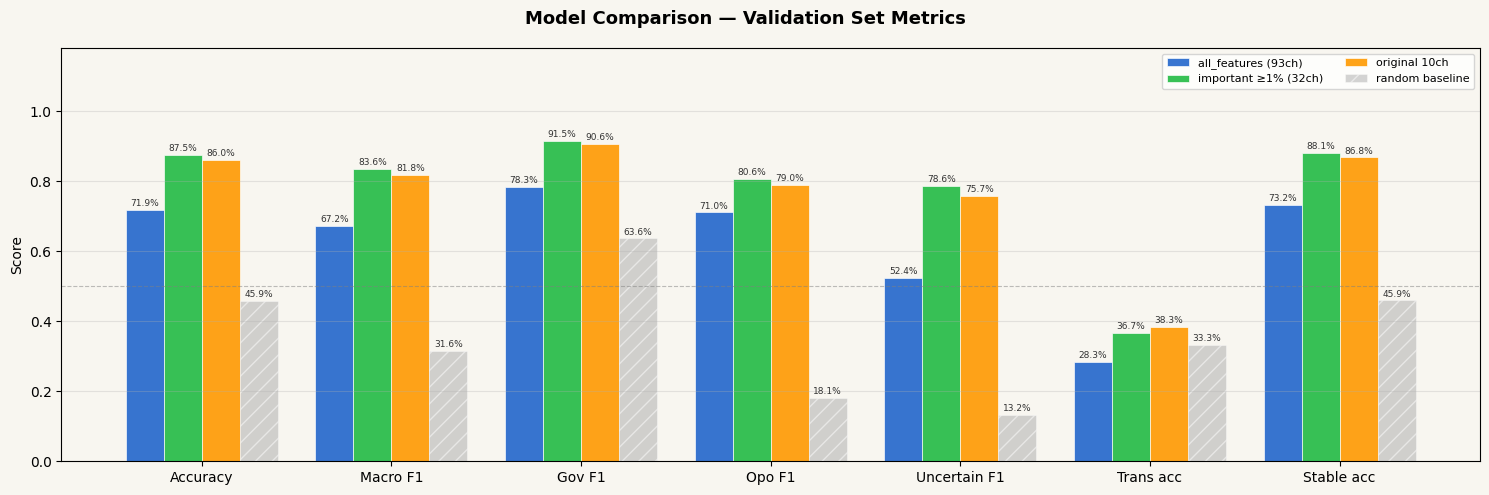

Metrics comparison chart saved.


In [99]:

# ── Summary metrics bar chart — all models + random baseline ──────────────────
metrics_to_plot = {
    'Accuracy'    : [r['acc']                               for r in results.values()],
    'Macro F1'    : [r['report']['macro avg']['f1-score']   for r in results.values()],
    'Gov F1'      : [r['report']['gov']['f1-score']         for r in results.values()],
    'Opo F1'      : [r['report']['opo']['f1-score']         for r in results.values()],
    'Uncertain F1': [r['report']['uncertain']['f1-score']   for r in results.values()],
    'Trans acc'   : [r['trans_acc']                         for r in results.values()],
    'Stable acc'  : [r['stable_acc']                        for r in results.values()],
}
model_names = list(results.keys())
n_metrics   = len(metrics_to_plot)
n_models    = len(model_names)
palette     = ['#2266CC', '#22BB44', '#FF9900', '#AAAAAA'][:n_models]   # grey for random

x       = np.arange(n_metrics)
width   = 0.8 / n_models
offsets = [(i - (n_models - 1) / 2) * width for i in range(n_models)]

fig, ax = plt.subplots(figsize=(15, 5), facecolor='#F8F6F0')
ax.set_facecolor('#F8F6F0')
fig.suptitle('Model Comparison — Validation Set Metrics', fontsize=13, fontweight='bold')

for i, (name, color, offset) in enumerate(zip(model_names, palette, offsets)):
    vals  = [metrics_to_plot[m][i] for m in metrics_to_plot]
    alpha = 0.5 if 'random' in name else 0.9
    bars  = ax.bar(x + offset, vals, width, label=name, color=color,
                   edgecolor='white', linewidth=0.5, alpha=alpha,
                   hatch='//' if 'random' in name else '')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f'{v:.1%}', ha='center', va='bottom', fontsize=6.5, color='#333333')

ax.set_xticks(x)
ax.set_xticklabels(list(metrics_to_plot.keys()), fontsize=10)
ax.set_ylim(0, 1.18)
ax.set_ylabel('Score')
ax.legend(fontsize=8, loc='upper right', ncol=2)
ax.axhline(0.5, color='grey', ls='--', lw=0.8, alpha=0.5)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
fig.savefig(OUT_DIR / 'eval_comparison_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print('Metrics comparison chart saved.')


AUC-ROC  (macro / gov / opo / uncertain)  — Overall
  all_features (93ch)         macro=0.899  gov=0.872  opo=0.899  unc=0.926
  important ≥1% (32ch)        macro=0.960  gov=0.944  opo=0.953  unc=0.982
  original 10ch               macro=0.952  gov=0.935  opo=0.943  unc=0.978
  random baseline             macro=0.500  gov=0.500  opo=0.500  unc=0.500

AUC-ROC  — Transitions only
  all_features (93ch)         macro=0.538  gov=0.464  opo=0.514  unc=0.598  (n=60)
  important ≥1% (32ch)        macro=0.623  gov=0.451  opo=0.590  unc=0.784  (n=60)
  original 10ch               macro=0.621  gov=0.435  opo=0.522  unc=0.868  (n=60)
  random baseline             macro=0.500  gov=0.500  opo=0.500  unc=0.500  (n=60)

Avg Precision  — Overall
  all_features (93ch)         macro=0.793  gov=0.917  opo=0.776  unc=0.686
  important ≥1% (32ch)        macro=0.916  gov=0.960  opo=0.908  unc=0.879
  original 10ch               macro=0.899  gov=0.958  opo=0.886  unc=0.853
  random baseline             macro=

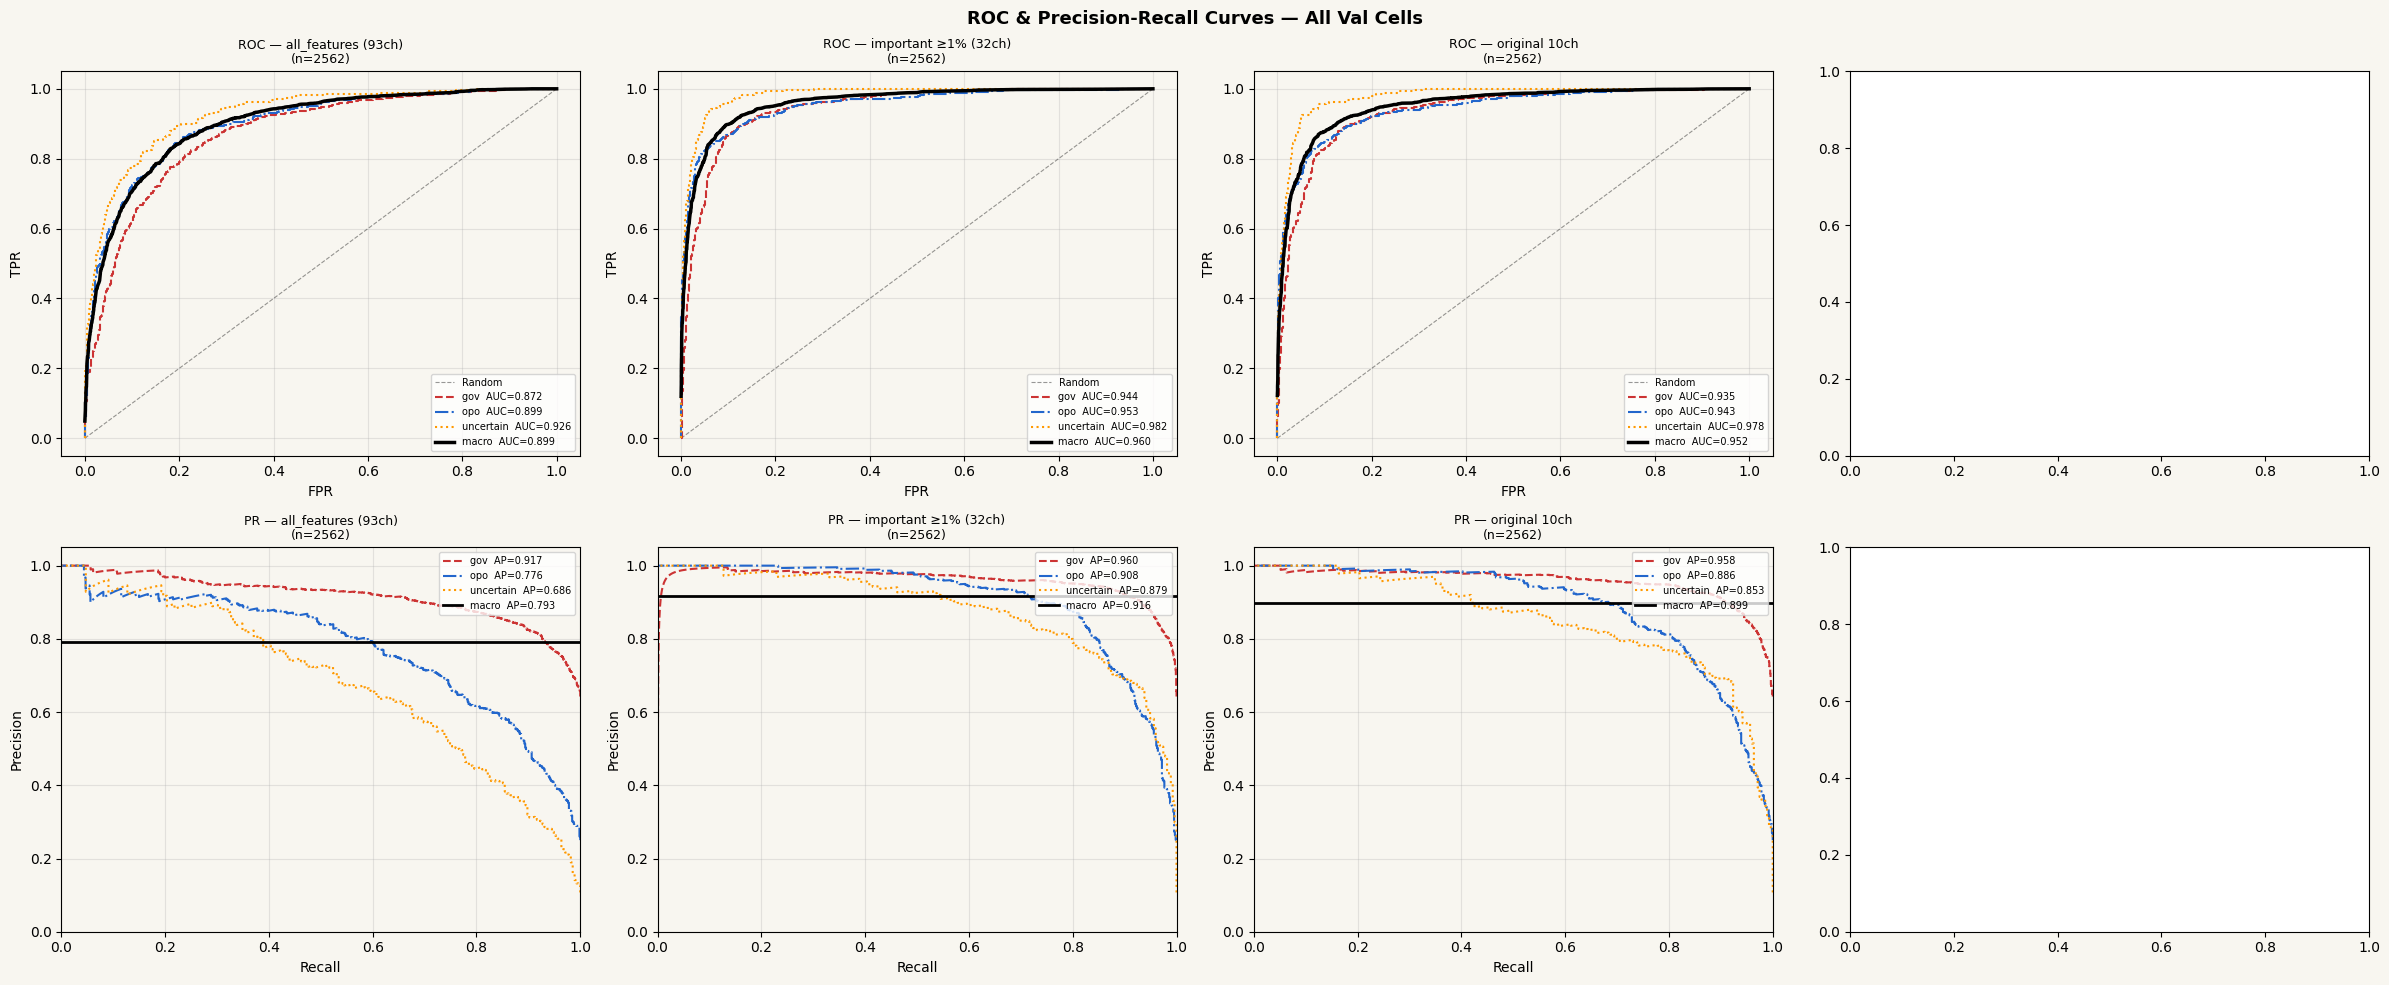

Saved: /Users/felipe/Documents/BSE/Thesis/territorial_control_dsdm_master_project/models/focal_mask_all_features/eval_roc_pr_overall.png


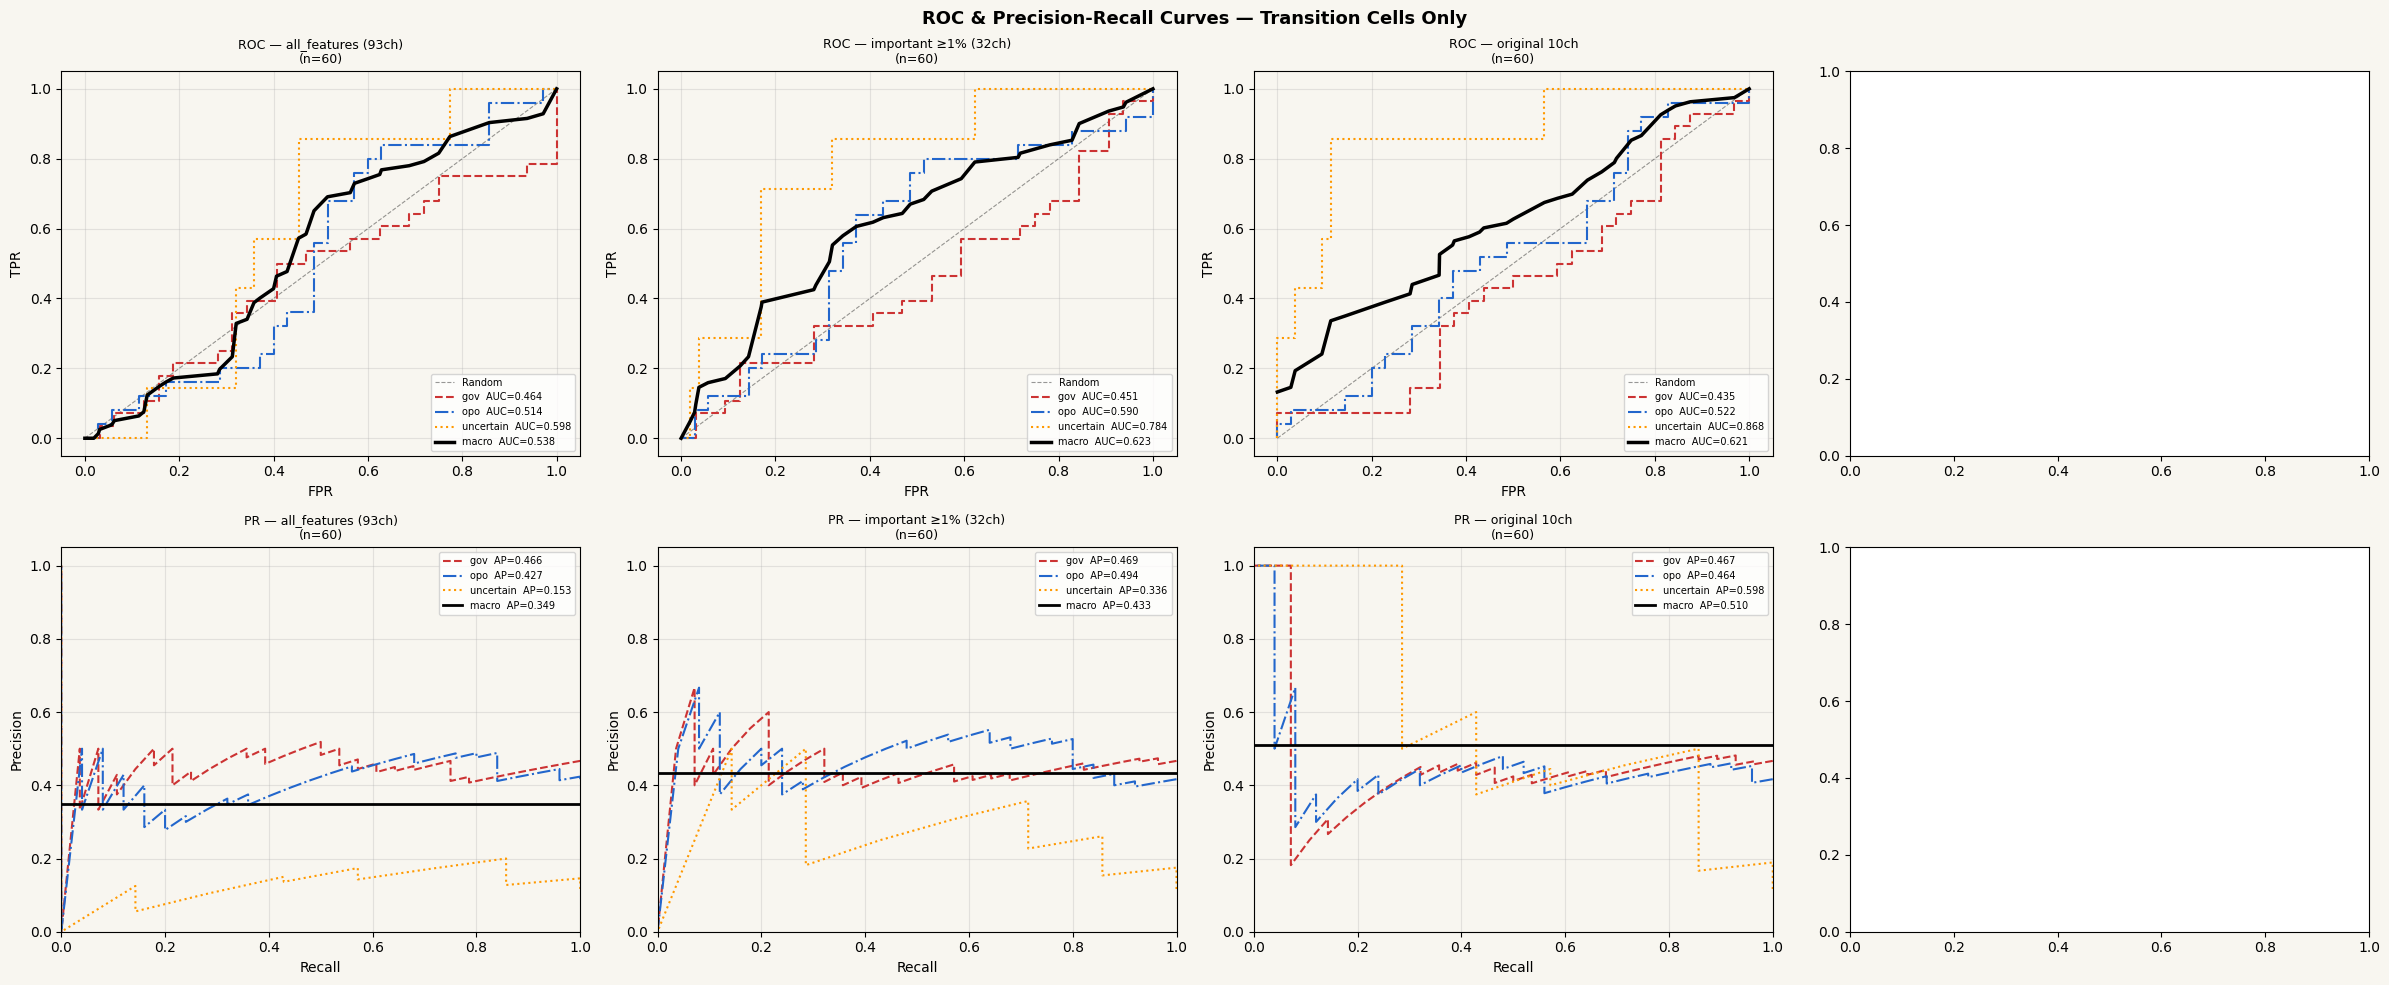

Saved: /Users/felipe/Documents/BSE/Thesis/territorial_control_dsdm_master_project/models/focal_mask_all_features/eval_roc_pr_transitions.png


In [100]:

# ── ROC & Precision-Recall curves — overall + transition cells ────────────────
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
from sklearn.preprocessing import label_binarize

PROB_COLS  = ['prob_gov', 'prob_opo', 'prob_uncertain']
CLS_COLORS = {'gov': '#CC3333', 'opo': '#2266CC', 'uncertain': '#FF9900', 'macro': 'black'}
CLS_LS     = {'gov': '--', 'opo': '-.', 'uncertain': ':', 'macro': '-'}


def compute_curves(df, trans_keys=None):
    """
    Returns dict with roc and pr data per class + macro.
    trans_keys: set of (priogrid_gid, year_month) tuples for transition cells.
    """
    val = df[df['is_train_month'] == False].copy()
    val['true_int'] = val['true_class'].map(LABEL_MAP_R)

    if trans_keys is not None:
        mask = val.apply(lambda r: (r['priogrid_gid'], r['year_month']) in trans_keys, axis=1)
        val  = val[mask]

    if len(val) == 0 or not all(c in val.columns for c in PROB_COLS):
        return None

    y_true = val['true_int'].values
    y_prob = val[PROB_COLS].values
    y_bin  = label_binarize(y_true, classes=[0, 1, 2])

    roc, pr = {}, {}
    for i, cls in enumerate(CLASS_NAMES):
        fpr, tpr, _ = roc_curve(y_bin[:, i], y_prob[:, i])
        roc[cls]    = {'fpr': fpr, 'tpr': tpr, 'auc': auc(fpr, tpr)}
        prec, rec, _= precision_recall_curve(y_bin[:, i], y_prob[:, i])
        pr[cls]     = {'prec': prec, 'rec': rec,
                       'ap': average_precision_score(y_bin[:, i], y_prob[:, i])}

    # macro ROC (interpolate on common fpr grid)
    all_fpr  = np.unique(np.concatenate([roc[c]['fpr'] for c in CLASS_NAMES]))
    mean_tpr = sum(np.interp(all_fpr, roc[c]['fpr'], roc[c]['tpr']) for c in CLASS_NAMES) / 3
    roc['macro'] = {'fpr': all_fpr, 'tpr': mean_tpr, 'auc': auc(all_fpr, mean_tpr)}
    pr['macro']  = {'ap': np.mean([pr[c]['ap'] for c in CLASS_NAMES])}

    return {'roc': roc, 'pr': pr, 'n': len(val)}


# Build transition key sets per variant
trans_keys_per = {
    name: set(zip(r['trans_only_df']['priogrid_gid'], r['trans_only_df']['year_month']))
    for name, r in results.items()
}

curves_overall = {name: compute_curves(df)
                  for name, df in VARIANTS.items()}
curves_trans   = {name: compute_curves(df, trans_keys_per.get(name))
                  for name, df in VARIANTS.items()}

# ── Print AUC / AP summary table ──────────────────────────────────────────────
print('AUC-ROC  (macro / gov / opo / uncertain)  — Overall')
for name, c in curves_overall.items():
    if c is None: continue
    print(f'  {name:<26}  macro={c["roc"]["macro"]["auc"]:.3f} '
          f' gov={c["roc"]["gov"]["auc"]:.3f}'
          f'  opo={c["roc"]["opo"]["auc"]:.3f}'
          f'  unc={c["roc"]["uncertain"]["auc"]:.3f}')

print('\nAUC-ROC  — Transitions only')
for name, c in curves_trans.items():
    if c is None: continue
    print(f'  {name:<26}  macro={c["roc"]["macro"]["auc"]:.3f} '
          f' gov={c["roc"]["gov"]["auc"]:.3f}'
          f'  opo={c["roc"]["opo"]["auc"]:.3f}'
          f'  unc={c["roc"]["uncertain"]["auc"]:.3f}  (n={c["n"]})')

print('\nAvg Precision  — Overall')
for name, c in curves_overall.items():
    if c is None: continue
    print(f'  {name:<26}  macro={c["pr"]["macro"]["ap"]:.3f} '
          f' gov={c["pr"]["gov"]["ap"]:.3f}'
          f'  opo={c["pr"]["opo"]["ap"]:.3f}'
          f'  unc={c["pr"]["uncertain"]["ap"]:.3f}')

print('\nAvg Precision  — Transitions only')
for name, c in curves_trans.items():
    if c is None: continue
    print(f'  {name:<26}  macro={c["pr"]["macro"]["ap"]:.3f} '
          f' gov={c["pr"]["gov"]["ap"]:.3f}'
          f'  opo={c["pr"]["opo"]["ap"]:.3f}'
          f'  unc={c["pr"]["uncertain"]["ap"]:.3f}  (n={c["n"]})')


def plot_roc_pr(curves_dict, title_suffix, out_suffix):
    names      = [n for n, c in curves_dict.items() if c is not None]
    n_variants = len(names)
    palette_m  = ['#2266CC', '#22BB44', '#FF9900'][:n_variants]

    fig, axes = plt.subplots(2, n_variants, figsize=(6 * n_variants, 10),
                             facecolor='#F8F6F0')
    if n_variants == 1:
        axes = axes.reshape(2, 1)
    fig.suptitle(f'ROC & Precision-Recall Curves — {title_suffix}',
                 fontsize=13, fontweight='bold')

    for col, (name, col_color) in enumerate(zip(names, palette_m)):
        c = curves_dict[name]

        # ROC
        ax = axes[0, col]
        ax.set_facecolor('#F8F6F0')
        ax.plot([0, 1], [0, 1], 'k--', lw=0.8, alpha=0.4, label='Random')
        for cls in CLASS_NAMES + ['macro']:
            rd = c['roc'][cls]
            lw = 2.5 if cls == 'macro' else 1.5
            ax.plot(rd['fpr'], rd['tpr'], color=CLS_COLORS[cls], ls=CLS_LS[cls],
                    lw=lw, label=f'{cls}  AUC={rd["auc"]:.3f}')
        ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
        ax.set_title(f'ROC — {name}\n(n={c["n"]})', fontsize=9)
        ax.legend(fontsize=7, loc='lower right')
        ax.grid(True, alpha=0.3)

        # PR
        ax = axes[1, col]
        ax.set_facecolor('#F8F6F0')
        for cls in CLASS_NAMES:
            pd_ = c['pr'][cls]
            ax.plot(pd_['rec'], pd_['prec'], color=CLS_COLORS[cls], ls=CLS_LS[cls],
                    lw=1.5, label=f'{cls}  AP={pd_["ap"]:.3f}')
        macro_ap = c['pr']['macro']['ap']
        ax.axhline(macro_ap, color='black', lw=2, ls='-',
                   label=f'macro  AP={macro_ap:.3f}')
        ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
        ax.set_title(f'PR — {name}\n(n={c["n"]})', fontsize=9)
        ax.legend(fontsize=7, loc='upper right')
        ax.grid(True, alpha=0.3)
        ax.set_xlim(0, 1); ax.set_ylim(0, 1.05)

    plt.tight_layout()
    save_path = OUT_DIR / f'eval_roc_pr_{out_suffix}.png'
    fig.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {save_path}')


plot_roc_pr(curves_overall, 'All Val Cells',       'overall')
plot_roc_pr(curves_trans,   'Transition Cells Only', 'transitions')


## Average Precision comparison vs. random baseline

Average Precision (AP) summarises the full Precision-Recall curve as a single number.
For multi-class problems the **random baseline AP equals the class proportion** in the
validation set — a classifier that draws randomly will match the prevalence of each class.
Comparing model AP to this baseline shows how much real signal each model captures,
independently of class imbalance.

Validation set class proportions (= random AP per class):
  gov         : 0.642
  opo         : 0.250
  uncertain   : 0.107
  macro       : 0.333

Model                                gov         opo   uncertain       macro
----------------------------------------------------------------------------
all_features (93ch)                0.917       0.776       0.686       0.793
important ≥1% (32ch)               0.960       0.908       0.879       0.916
original 10ch                      0.958       0.886       0.853       0.899
random baseline                    0.642       0.250       0.107       0.333
----------------------------------------------------------------------------
Lift over random (macro AP):
  all_features (93ch)       : 0.793 / 0.333 = 2.38x
  important ≥1% (32ch)      : 0.916 / 0.333 = 2.75x
  original 10ch             : 0.899 / 0.333 = 2.70x


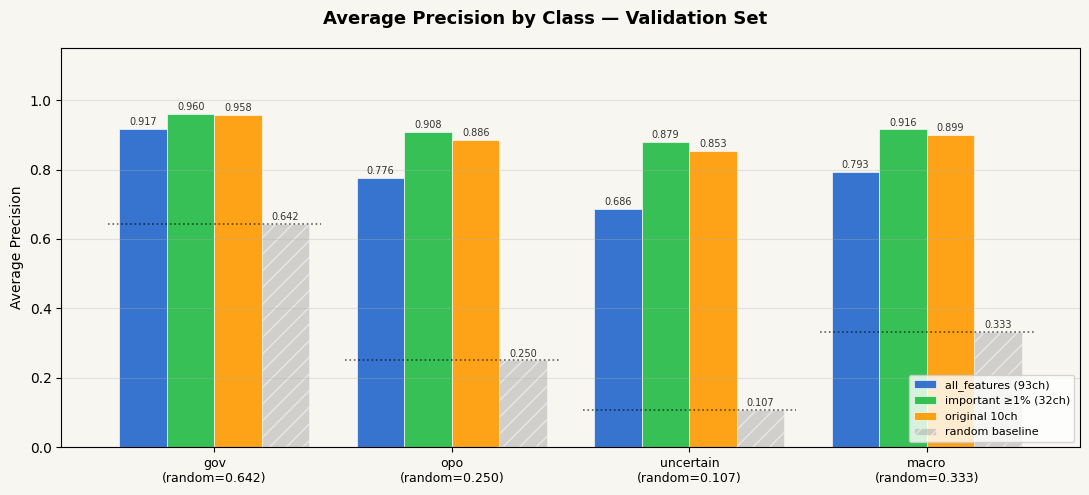

AP comparison plot saved.


In [101]:
# ── Average Precision — all variants vs. random baseline ────────────────────
from sklearn.metrics import average_precision_score
from sklearn.preprocessing import label_binarize

PROB_COLS = ['prob_gov', 'prob_opo', 'prob_uncertain']

# Class proportions in the validation set = random-classifier AP per class
val_ref   = pred_df[pred_df['is_train_month'] == False].copy()
val_ref['true_int'] = val_ref['true_class'].map(LABEL_MAP_R)
class_props = val_ref['true_class'].value_counts(normalize=True).reindex(CLASS_NAMES)
rand_macro  = class_props.mean()

print('Validation set class proportions (= random AP per class):')
for cls, p in class_props.items():
    print(f'  {cls:12s}: {p:.3f}')
print(f'  {"macro":12s}: {rand_macro:.3f}')
print()

# Compute AP for every variant that has probability columns
ap_rows = []
for name, df in VARIANTS.items():
    val = df[df['is_train_month'] == False].copy()
    val['true_int'] = val['true_class'].map(LABEL_MAP_R)
    if not all(c in val.columns for c in PROB_COLS):
        continue  # skip if no probability scores (e.g. hard random baseline)
    y_bin  = label_binarize(val['true_int'].values, classes=[0, 1, 2])
    y_prob = val[PROB_COLS].values
    aps = {cls: average_precision_score(y_bin[:, i], y_prob[:, i])
           for i, cls in enumerate(CLASS_NAMES)}
    aps['macro'] = sum(aps.values()) / len(CLASS_NAMES)
    ap_rows.append({'model': name, **aps})

# Random baseline row — use class proportions directly (constant prob scores
# give the same AP as prevalence, but we avoid adding it twice via the loop)
rand_row = {'model': 'random baseline',
            **{cls: class_props[cls] for cls in CLASS_NAMES},
            'macro': rand_macro}
ap_rows = [r for r in ap_rows if r['model'] != 'random baseline']
ap_rows.append(rand_row)

ap_df = pd.DataFrame(ap_rows).set_index('model')

# ── Print table with lift over random ────────────────────────────────────────
print(f'{"Model":<28}' + ''.join(f'{c:>12}' for c in CLASS_NAMES + ['macro']))
print('-' * 76)
for model, row in ap_df.iterrows():
    vals = ''.join(f'{row[c]:>12.3f}' for c in CLASS_NAMES + ['macro'])
    print(f'{model:<28}{vals}')
print('-' * 76)
print('Lift over random (macro AP):')
for model, row in ap_df.iterrows():
    if model == 'random baseline': continue
    lift = row['macro'] / rand_macro
    print(f'  {model:<26}: {row["macro"]:.3f} / {rand_macro:.3f} = {lift:.2f}x')

# ── Bar chart ────────────────────────────────────────────────────────────────
metrics_ap = CLASS_NAMES + ['macro']
model_names_ap = ap_df.index.tolist()
n_m = len(model_names_ap)
palette_ap = ['#2266CC', '#22BB44', '#FF9900', '#AAAAAA'][:n_m]

x_ap    = np.arange(len(metrics_ap))
w_ap    = 0.8 / n_m
offsets = [(i - (n_m - 1) / 2) * w_ap for i in range(n_m)]

fig, ax = plt.subplots(figsize=(11, 5), facecolor='#F8F6F0')
ax.set_facecolor('#F8F6F0')
fig.suptitle('Average Precision by Class — Validation Set', fontsize=13, fontweight='bold')

for i, (name, color, offset) in enumerate(zip(model_names_ap, palette_ap, offsets)):
    vals  = [ap_df.loc[name, c] for c in metrics_ap]
    alpha = 0.5 if 'random' in name else 0.9
    hatch = '//' if 'random' in name else ''
    bars  = ax.bar(x_ap + offset, vals, w_ap, label=name, color=color,
                   edgecolor='white', linewidth=0.5, alpha=alpha, hatch=hatch)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f'{v:.3f}', ha='center', va='bottom', fontsize=7, color='#333333')

# Random baseline reference lines per class
for j, cls in enumerate(metrics_ap):
    ref_val = rand_row[cls]
    ax.plot([j - 0.45, j + 0.45], [ref_val, ref_val],
            color='black', lw=1.2, ls=':', alpha=0.6)

ax.set_xticks(x_ap)
ax.set_xticklabels([f'{c}\n(random={rand_row[c]:.3f})' for c in metrics_ap], fontsize=9)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Average Precision')
ax.legend(fontsize=8, loc='lower right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
fig.savefig(OUT_DIR / 'eval_ap_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('AP comparison plot saved.')


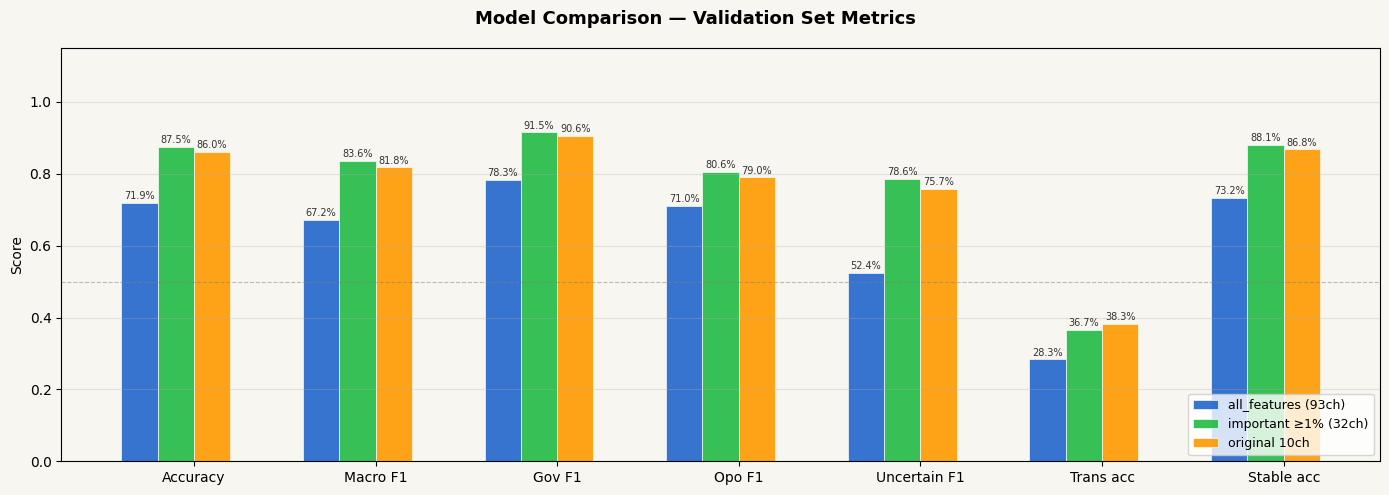

Metrics comparison chart saved.


In [102]:

# ── Summary metrics bar chart — 3-model comparison ───────────────────────────
metrics_to_plot = {
    'Accuracy'   : [r['acc']                               for r in results.values()],
    'Macro F1'   : [r['report']['macro avg']['f1-score']   for r in results.values()],
    'Gov F1'     : [r['report']['gov']['f1-score']         for r in results.values()],
    'Opo F1'     : [r['report']['opo']['f1-score']         for r in results.values()],
    'Uncertain F1': [r['report']['uncertain']['f1-score']  for r in results.values()],
    'Trans acc'  : [r['trans_acc']                         for r in results.values()],
    'Stable acc' : [r['stable_acc']                        for r in results.values()],
}
model_names = list(results.keys())
n_metrics   = len(metrics_to_plot)
n_models    = len(model_names)
palette     = ['#2266CC', '#22BB44', '#FF9900'][:n_models]

x      = np.arange(n_metrics)
width  = 0.8 / n_models
offsets = [(i - (n_models - 1) / 2) * width for i in range(n_models)]

fig, ax = plt.subplots(figsize=(14, 5), facecolor='#F8F6F0')
ax.set_facecolor('#F8F6F0')
fig.suptitle('Model Comparison — Validation Set Metrics', fontsize=13, fontweight='bold')

for i, (name, color, offset) in enumerate(zip(model_names, palette, offsets)):
    vals = [metrics_to_plot[m][i] for m in metrics_to_plot]
    bars = ax.bar(x + offset, vals, width, label=name, color=color,
                  edgecolor='white', linewidth=0.5, alpha=0.9)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f'{v:.1%}', ha='center', va='bottom', fontsize=7, color='#333333')

ax.set_xticks(x)
ax.set_xticklabels(list(metrics_to_plot.keys()), fontsize=10)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score')
ax.legend(fontsize=9, loc='lower right')
ax.axhline(0.5, color='grey', ls='--', lw=0.8, alpha=0.5)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
fig.savefig(OUT_DIR / 'eval_comparison_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print('Metrics comparison chart saved.')


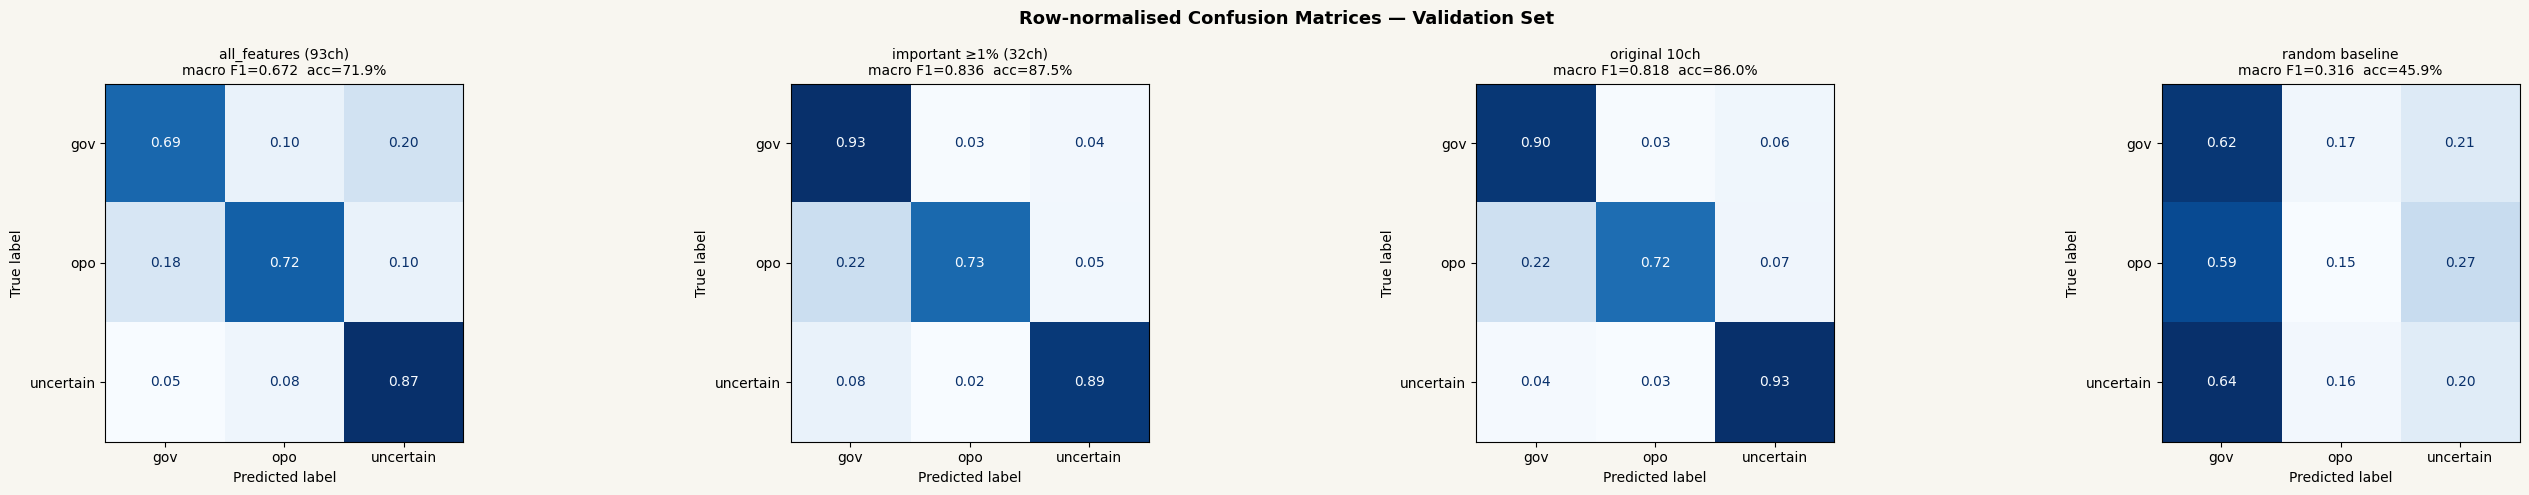

Confusion matrix panel saved.


In [103]:

# ── Confusion matrices — one panel per variant ────────────────────────────────
n_variants = len(results)
fig, axes  = plt.subplots(1, n_variants, figsize=(7 * n_variants, 5), facecolor='#F8F6F0')
if n_variants == 1:
    axes = [axes]
fig.suptitle('Row-normalised Confusion Matrices — Validation Set', fontsize=13, fontweight='bold')

for ax, (name, r) in zip(axes, results.items()):
    mf1 = r['report']['macro avg']['f1-score']
    acc = r['acc']
    ConfusionMatrixDisplay(r['cm_norm'], display_labels=CLASS_NAMES).plot(
        ax=ax, cmap='Blues', colorbar=False, values_format='.2f')
    ax.set_title(f'{name}\nmacro F1={mf1:.3f}  acc={acc:.1%}', fontsize=10)
    ax.set_facecolor('#F8F6F0')

plt.tight_layout()
fig.savefig(OUT_DIR / 'eval_comparison_cm.png', dpi=150, bbox_inches='tight')
plt.show()
print('Confusion matrix panel saved.')


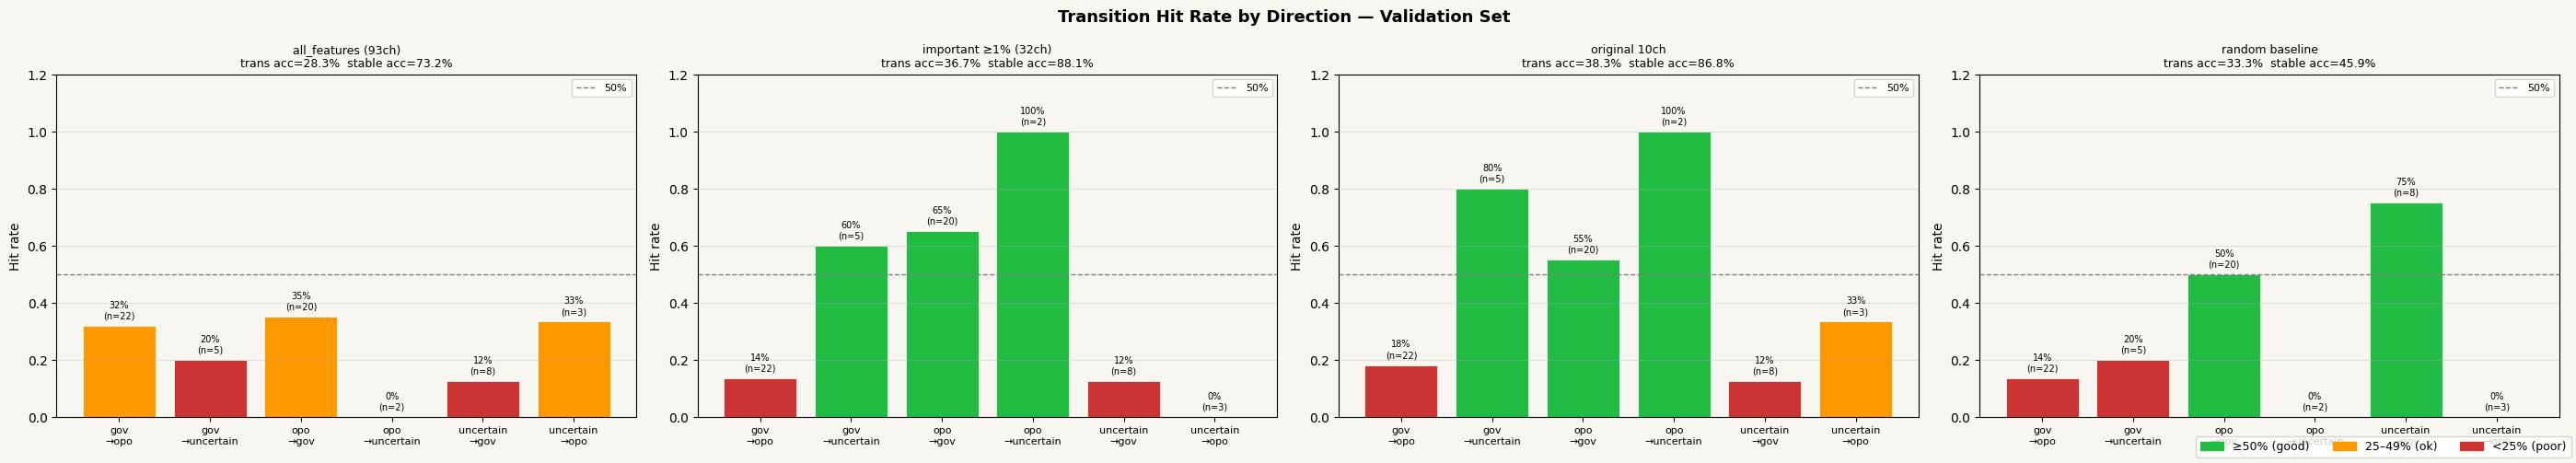

Transition comparison saved.

COMPLETE.


In [104]:

# ── Transition hit-rate comparison ────────────────────────────────────────────
directions   = [(f, t) for f in CLASS_NAMES for t in CLASS_NAMES if f != t]
n_variants   = len(results)
fig, axes    = plt.subplots(1, n_variants, figsize=(7 * n_variants, 5), facecolor='#F8F6F0')
if n_variants == 1:
    axes = [axes]
fig.suptitle('Transition Hit Rate by Direction — Validation Set', fontsize=13, fontweight='bold')

for ax, (name, r) in zip(axes, results.items()):
    tdf = r['trans_only_df']
    labels_bar, hit_rates_bar, counts_bar = [], [], []
    for from_c, to_c in directions:
        sub = tdf[(tdf['from_cls'] == from_c) & (tdf['to_cls'] == to_c)]
        if len(sub) == 0:
            continue
        labels_bar.append(f'{from_c}\n→{to_c}')
        hit_rates_bar.append(sub['hit'].mean())
        counts_bar.append(len(sub))

    x          = np.arange(len(labels_bar))
    bar_colors = ['#22BB44' if h >= 0.5 else ('#FF9900' if h >= 0.25 else '#CC3333')
                  for h in hit_rates_bar]
    bars = ax.bar(x, hit_rates_bar, color=bar_colors, edgecolor='white', linewidth=0.5)
    ax.axhline(0.5, color='grey', ls='--', lw=1, label='50%')
    ax.set_xticks(x); ax.set_xticklabels(labels_bar, fontsize=8)
    ax.set_ylim(0, 1.2)
    ax.set_ylabel('Hit rate')
    ax.set_title(f'{name}\ntrans acc={r["trans_acc"]:.1%}  stable acc={r["stable_acc"]:.1%}', fontsize=9)
    ax.set_facecolor('#F8F6F0')
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)
    for bar, h, n in zip(bars, hit_rates_bar, counts_bar):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
                f'{h:.0%}\n(n={n})', ha='center', va='bottom', fontsize=7)

patches = [
    mpatches.Patch(color='#22BB44', label='≥50% (good)'),
    mpatches.Patch(color='#FF9900', label='25–49% (ok)'),
    mpatches.Patch(color='#CC3333', label='<25% (poor)'),
]
fig.legend(handles=patches, loc='lower right', fontsize=9, ncol=3)

plt.tight_layout()
fig.savefig(OUT_DIR / 'eval_comparison_transitions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Transition comparison saved.')
print('\nCOMPLETE.')


## Spatial correctness maps — all cells

Each panel shows one validation month × one model variant. Every labelled PRIOGRID cell
is coloured **green** if the model predicted the correct control label and **red** if it
missed. White pixels are outside Myanmar's labelled area.

Months are chosen to span early, mid, and late validation period, favouring months with
more territorial transitions so spatial errors are easier to spot.

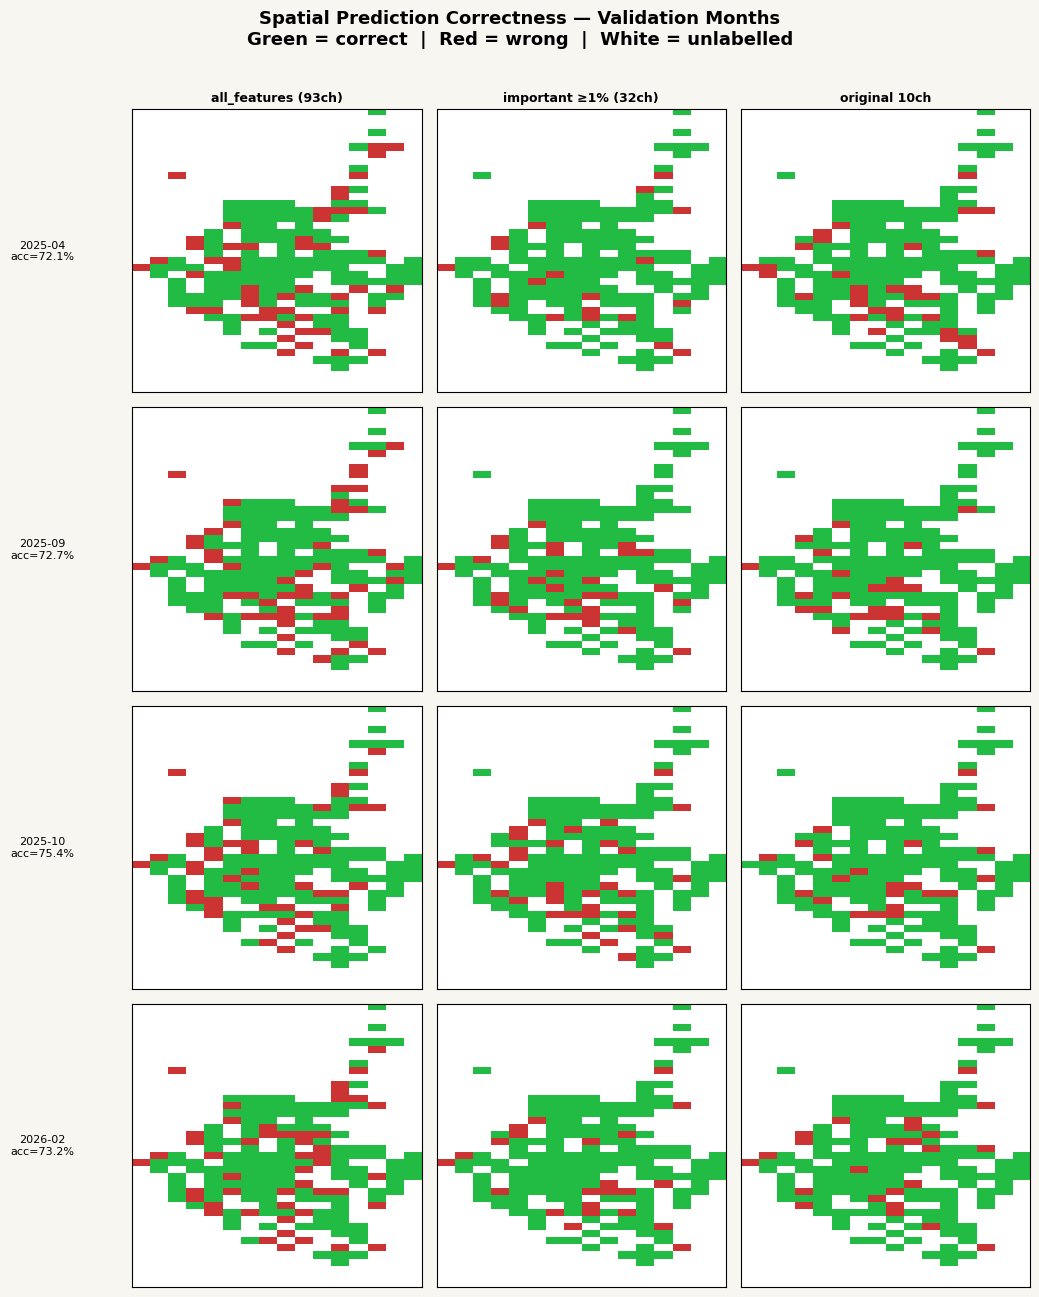

Spatial correctness map saved.


In [105]:
# ── Spatial correctness — all cells ─────────────────────────────────────────
import matplotlib.colors as mcolors

# Months spread across the val period, picked for transition activity
PLOT_MONTHS = ['2025-04', '2025-09', '2025-10', '2026-02']

# Skip random baseline — spatial noise adds nothing here
SPATIAL_VARIANTS = {k: v for k, v in VARIANTS.items() if 'random' not in k}
n_months = len(PLOT_MONTHS)
n_models = len(SPATIAL_VARIANTS)

fig, axes = plt.subplots(
    n_months, n_models,
    figsize=(3.5 * n_models, 3.2 * n_months),
    facecolor='#F8F6F0'
)
fig.suptitle(
    'Spatial Prediction Correctness — Validation Months\n'
    'Green = correct  |  Red = wrong  |  White = unlabelled',
    fontsize=13, fontweight='bold', y=1.01
)

correct_cmap = mcolors.ListedColormap(['#CC3333', '#22BB44'])

for row_i, month in enumerate(PLOT_MONTHS):
    for col_j, (name, df) in enumerate(SPATIAL_VARIANTS.items()):
        ax = axes[row_i, col_j]

        # Build correctness raster: 1=correct, 0=wrong, NaN=no cell
        canvas = np.full((PAD_H, PAD_W), np.nan)
        month_df = df[df['year_month'] == month]
        for _, r in month_df.iterrows():
            gid = r['priogrid_gid']
            if gid not in gid_to_local:
                continue
            lr = gid_to_local[gid]['local_row']
            lc = gid_to_local[gid]['local_col']
            canvas[lr, lc] = 1.0 if r['pred_class'] == r['true_class'] else 0.0

        ax.imshow(canvas, cmap=correct_cmap, vmin=0, vmax=1,
                  interpolation='nearest', aspect='auto')
        ax.set_xticks([])
        ax.set_yticks([])

        if row_i == 0:
            ax.set_title(name, fontsize=9, fontweight='bold')
        if col_j == 0:
            acc = (month_df['pred_class'] == month_df['true_class']).mean()
            ax.set_ylabel(f'{month}\nacc={acc:.1%}', fontsize=8,
                          rotation=0, labelpad=65, va='center')

plt.tight_layout()
fig.savefig(OUT_DIR / 'spatial_correctness_all.png', dpi=150, bbox_inches='tight')
plt.show()
print('Spatial correctness map saved.')


## Spatial correctness maps — transition cells only

Same layout as above, but cells are colour-coded by whether a **territorial transition**
occurred that month (i.e. the true label changed from the previous month):

- **Green** — transition cell, model correctly predicted the new label
- **Red** — transition cell, model missed the change
- **Grey** — stable cell (no change), shown as background context

The row label reports how many transitions were hit out of the total for that month.
This view isolates the hardest prediction task: catching the moment a cell flips
between government, opposition, or uncertain control.

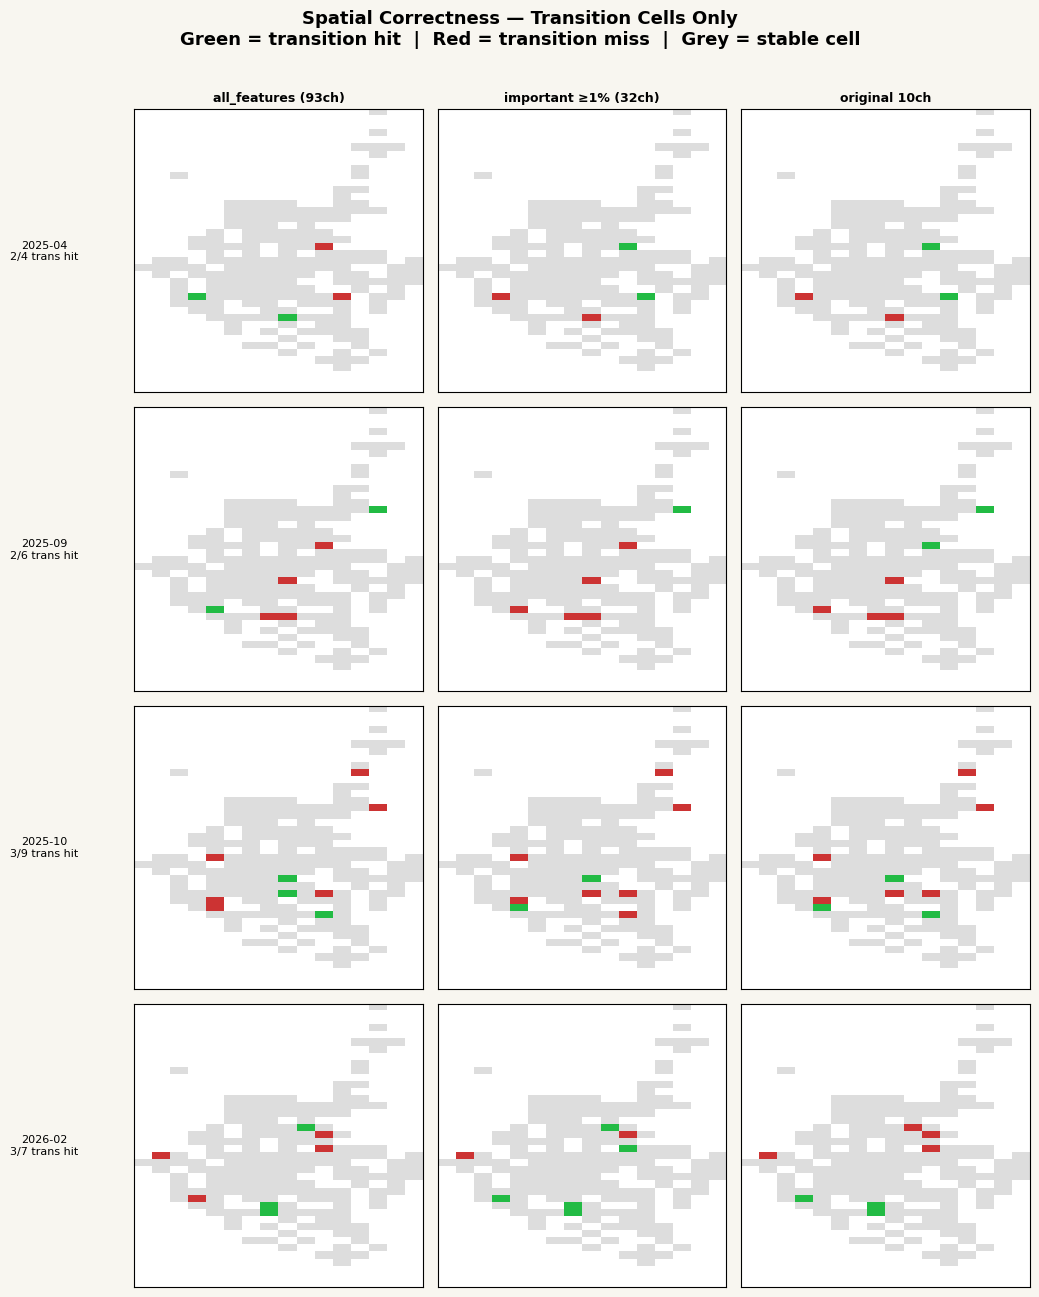

Transition correctness map saved.


In [106]:
# ── Spatial correctness — transition cells only ──────────────────────────────

# 3-colour map: 0=transition miss (red), 0.5=stable (grey), 1=transition hit (green)
trans_cmap   = mcolors.ListedColormap(['#CC3333', '#DDDDDD', '#22BB44'])
trans_bounds = [-0.1, 0.25, 0.75, 1.1]
trans_norm   = mcolors.BoundaryNorm(trans_bounds, trans_cmap.N)

fig, axes = plt.subplots(
    n_months, n_models,
    figsize=(3.5 * n_models, 3.2 * n_months),
    facecolor='#F8F6F0'
)
fig.suptitle(
    'Spatial Correctness — Transition Cells Only\n'
    'Green = transition hit  |  Red = transition miss  |  Grey = stable cell',
    fontsize=13, fontweight='bold', y=1.01
)

for row_i, month in enumerate(PLOT_MONTHS):
    for col_j, (name, df) in enumerate(SPATIAL_VARIANTS.items()):
        ax = axes[row_i, col_j]

        # Identify transition cells: true label differs from previous month's true label
        val_sorted = (
            df[df['is_train_month'] == False]
            .sort_values(['priogrid_gid', 'year_month'])
            .copy()
        )
        val_sorted['prev_true'] = val_sorted.groupby('priogrid_gid')['true_class'].shift(1)
        month_df = val_sorted[val_sorted['year_month'] == month].copy()
        month_df['is_trans'] = (
            month_df['prev_true'].notna() &
            (month_df['true_class'] != month_df['prev_true'])
        )

        # Build raster: NaN=no cell, 0.5=stable, 0=trans miss, 1=trans hit
        canvas = np.full((PAD_H, PAD_W), np.nan)
        for _, r in month_df.iterrows():
            gid = r['priogrid_gid']
            if gid not in gid_to_local:
                continue
            lr = gid_to_local[gid]['local_row']
            lc = gid_to_local[gid]['local_col']
            if r['is_trans']:
                canvas[lr, lc] = 1.0 if r['pred_class'] == r['true_class'] else 0.0
            else:
                canvas[lr, lc] = 0.5  # stable — grey background

        ax.imshow(canvas, cmap=trans_cmap, norm=trans_norm,
                  interpolation='nearest', aspect='auto')
        ax.set_xticks([])
        ax.set_yticks([])

        if row_i == 0:
            ax.set_title(name, fontsize=9, fontweight='bold')
        if col_j == 0:
            trans_cells = month_df[month_df['is_trans']]
            n_trans = len(trans_cells)
            n_hit   = (trans_cells['pred_class'] == trans_cells['true_class']).sum()
            ax.set_ylabel(f'{month}\n{n_hit}/{n_trans} trans hit', fontsize=8,
                          rotation=0, labelpad=65, va='center')

plt.tight_layout()
fig.savefig(OUT_DIR / 'spatial_correctness_transitions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Transition correctness map saved.')


## Feature importance & correlation with territorial transitions

**Left** — permutation importance of each of the 32 retained features
(relative macro-F1 drop when the channel is zeroed out in the trained model).

**Right** — Pearson (point-biserial) correlation between each feature and the binary
`is_transition` flag: 1 if a cell's true control label changed from the previous month,
0 otherwise. Transitions are rare (~5% of observations), so correlations are modest,
but positive values indicate features that tend to be elevated *around* transition events.

Transition events: 255 / 5238 obs (4.87%)


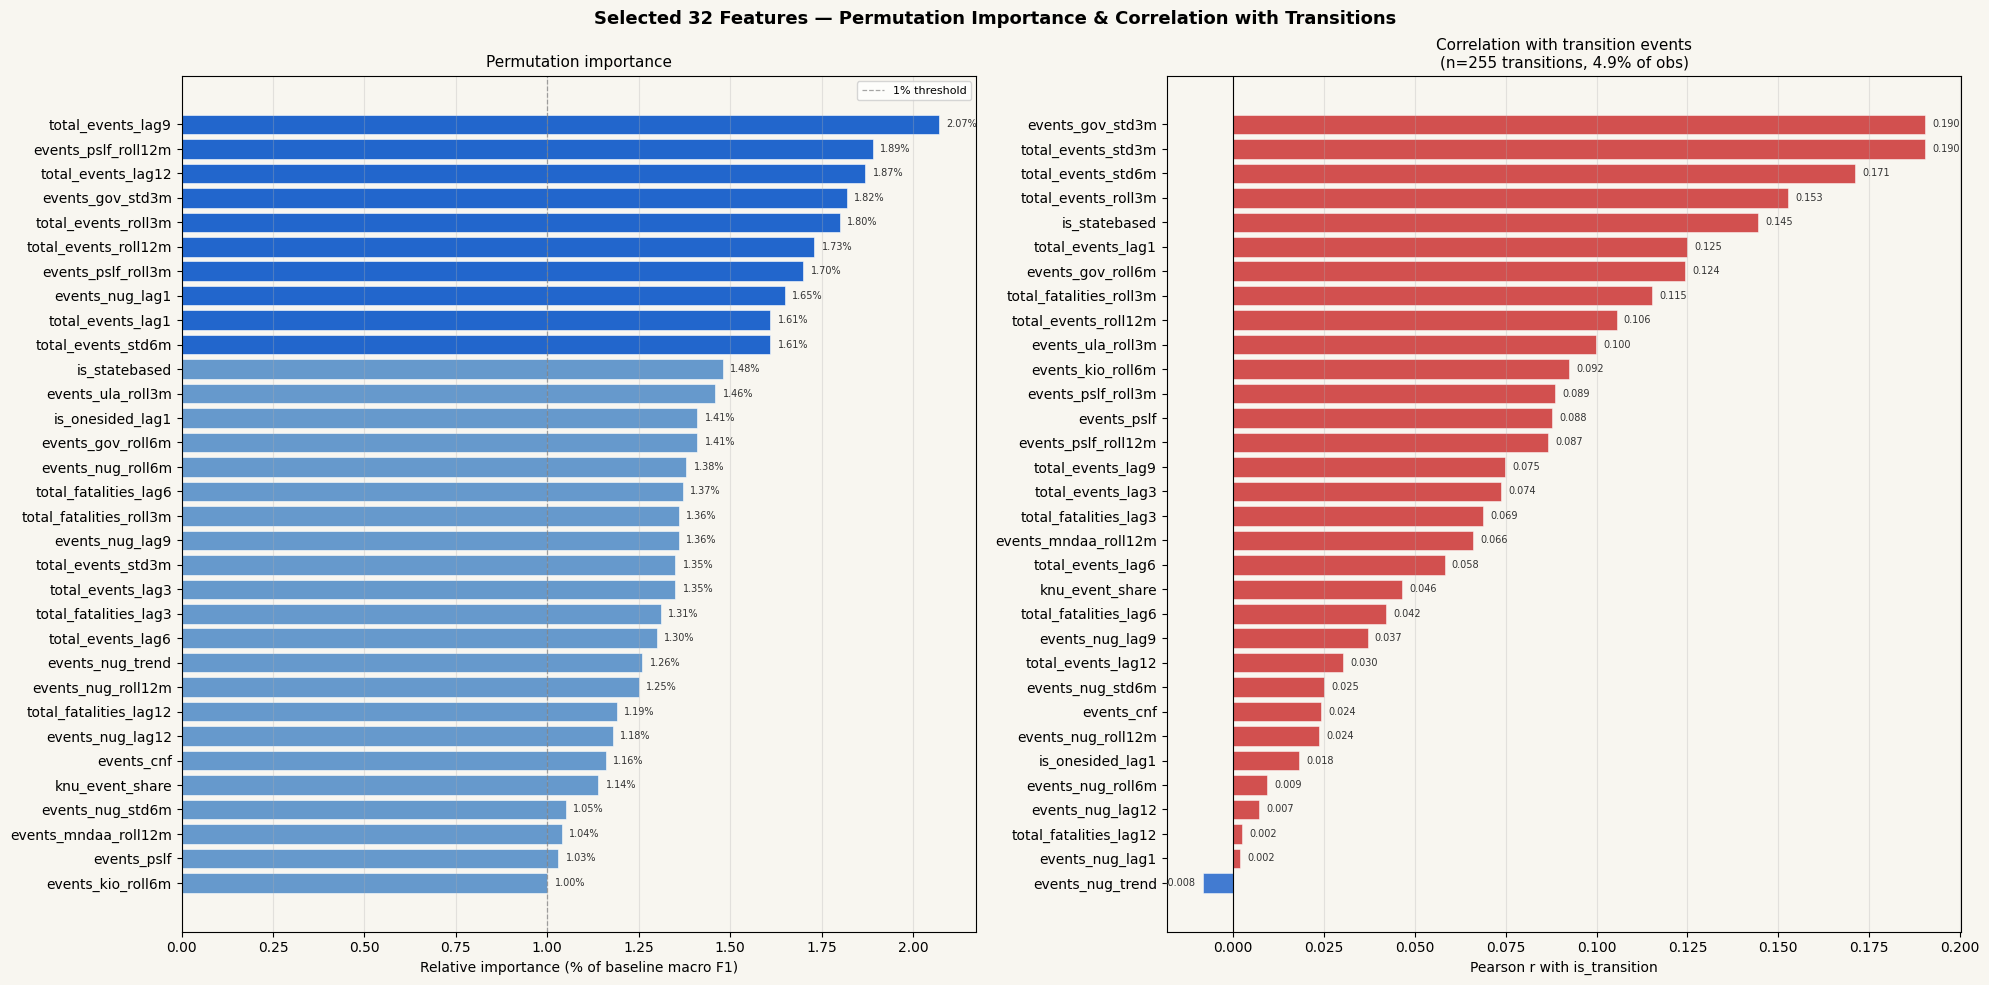

Feature importance + transition correlation plot saved.


In [107]:
# ── Feature importance + correlation with transition events ──────────────────

# Build is_transition: true label changes from the previous month for the same cell
labelled_sorted = labelled.sort_values(['priogrid_gid', 'year_month']).copy()
labelled_sorted['prev_label'] = labelled_sorted.groupby('priogrid_gid')['label_int'].shift(1)
labelled_sorted['is_transition'] = (
    (labelled_sorted['label_int'] != labelled_sorted['prev_label']) &
    labelled_sorted['prev_label'].notna()
).astype(float)

n_trans = int(labelled_sorted['is_transition'].sum())
pct     = labelled_sorted['is_transition'].mean()
print(f'Transition events: {n_trans} / {len(labelled_sorted)} obs ({pct:.2%})')

# Pearson correlation of each feature with is_transition
trans_corr = (
    labelled_sorted[IMP_FEATURES + ['is_transition']]
    .corr()['is_transition']
    .drop('is_transition')
    .sort_values(ascending=False)
)

# Importance sorted the same way as the bar chart (ascending, for horizontal bar)
imp32 = imp_df[imp_df['relative_importance_%'] >= 1.0].sort_values(
    'relative_importance_%', ascending=True
).reset_index(drop=True)

# ── Layout ───────────────────────────────────────────────────────────────────
fig, (ax_bar, ax_corr) = plt.subplots(
    1, 2, figsize=(20, 10), facecolor='#F8F6F0'
)
fig.suptitle(
    'Selected 32 Features — Permutation Importance & Correlation with Transitions',
    fontsize=13, fontweight='bold'
)

# ── Left: importance bar chart ────────────────────────────────────────────────
imp_colors = ['#2266CC' if v >= 1.5 else '#6699CC'
              for v in imp32['relative_importance_%']]
ax_bar.barh(imp32['feature'], imp32['relative_importance_%'],
            color=imp_colors, edgecolor='white', linewidth=0.4)
ax_bar.axvline(1.0, color='grey', ls='--', lw=0.9, alpha=0.7, label='1% threshold')
ax_bar.set_xlabel('Relative importance (% of baseline macro F1)')
ax_bar.set_title('Permutation importance', fontsize=11)
ax_bar.legend(fontsize=8)
ax_bar.grid(axis='x', alpha=0.3)
ax_bar.set_facecolor('#F8F6F0')
for i, (v, feat) in enumerate(zip(imp32['relative_importance_%'], imp32['feature'])):
    ax_bar.text(v + 0.02, i, f'{v:.2f}%', va='center', fontsize=7, color='#333333')

# ── Right: correlation with is_transition ─────────────────────────────────────
corr_colors = ['#CC3333' if v >= 0 else '#2266CC' for v in trans_corr.values]
ax_corr.barh(trans_corr.index, trans_corr.values,
             color=corr_colors, edgecolor='white', linewidth=0.4, alpha=0.85)
ax_corr.axvline(0, color='black', lw=0.8)
ax_corr.set_xlabel('Pearson r with is_transition')
ax_corr.set_title(
    f'Correlation with transition events\n'
    f'(n={n_trans} transitions, {pct:.1%} of obs)',
    fontsize=11
)
ax_corr.grid(axis='x', alpha=0.3)
ax_corr.set_facecolor('#F8F6F0')
ax_corr.invert_yaxis()
for i, (feat, v) in enumerate(trans_corr.items()):
    xpos  = v + 0.002 if v >= 0 else v - 0.002
    align = 'left' if v >= 0 else 'right'
    ax_corr.text(xpos, i, f'{v:.3f}', va='center', ha=align,
                 fontsize=7, color='#333333')

plt.tight_layout()
fig.savefig(OUT_DIR / 'feature_importance_transition_corr.png', dpi=150, bbox_inches='tight')
plt.show()
print('Feature importance + transition correlation plot saved.')
